In [23]:
# Fixed correlation analysis with proper data alignment
correlation_results = []

# Prepare market share data with proper date format
market_share_change = market_share_df.copy()
# Ensure Month column is datetime
market_share_change['Month'] = pd.to_datetime(market_share_change['Month'])

market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

# Convert market share months to period format for matching
market_share_change['Month_Period'] = market_share_change['Month'].dt.to_period('M')

print("=== Correlation Analysis ===")

for model in ['chatgpt', 'claude', 'gemini']:
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    
    if len(model_mentioned) > 0:
        # Calculate monthly sentiment metrics
        monthly_sentiment = model_mentioned.groupby('Month')[f'{model}_pred'].apply(
            lambda x: pd.Series({
                'net_sentiment': (x == 1).sum() - (x == -1).sum(),
                'positive_ratio': (x == 1).mean(),
                'negative_ratio': (x == -1).mean()
            })
        ).unstack()
        
        # Get corresponding market share change
        if model == 'chatgpt':
            market_col = 'ChatGPT_Change'
        elif model == 'claude':
            market_col = 'Claude_Change'
        elif model == 'gemini':
            market_col = 'Gemini_Change'
        
        # Align data by matching periods
        market_data = market_share_change.set_index('Month_Period')[market_col]
        
        # Find common periods
        common_periods = monthly_sentiment.index.intersection(market_data.index)
        print(f"\n{model.upper()}: {len(common_periods)} common months")
        
        if len(common_periods) >= 2:  # Need at least 2 points for correlation
            sentiment_aligned = monthly_sentiment.loc[common_periods, 'net_sentiment']
            market_aligned = market_data.loc[common_periods]
            
            # Remove any NaN values
            valid_mask = sentiment_aligned.notna() & market_aligned.notna()
            sentiment_clean = sentiment_aligned[valid_mask]
            market_clean = market_aligned[valid_mask]
            
            print(f"  Valid data points: {len(sentiment_clean)}")
            print(f"  Sentiment values: {sentiment_clean.tolist()}")
            print(f"  Market values: {market_clean.tolist()}")
            
            if len(sentiment_clean) >= 2 and sentiment_clean.std() > 0 and market_clean.std() > 0:
                correlation = sentiment_clean.corr(market_clean)
                correlation_results.append({
                    'Model': model.upper(),
                    'Correlation': correlation,
                    'Sample_Size': len(sentiment_clean),
                    'Sentiment_Range': f"{sentiment_clean.min():.1f} to {sentiment_clean.max():.1f}",
                    'Market_Range': f"{market_clean.min():.2f}% to {market_clean.max():.2f}%"
                })
                print(f"  Correlation: {correlation:.3f}")
            else:
                print(f"  Insufficient variation in data for correlation")
                print(f"  Sentiment std: {sentiment_clean.std():.3f}, Market std: {market_clean.std():.3f}")

# Create visualization
if correlation_results:
    corr_df = pd.DataFrame(correlation_results)
    
    plt.figure(figsize=(12, 8))
    
    # Create bar chart
    colors = ['#e74c3c', '#95a5a6', '#f39c12'][:len(corr_df)]
    bars = plt.bar(corr_df['Model'], corr_df['Correlation'], 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    
    # Add value labels on bars
    for i, (bar, row) in enumerate(zip(bars, corr_df.itertuples())):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (0.03 if height >= 0 else -0.06),
                f'{row.Correlation:.3f}\n(n={row.Sample_Size})', 
                ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=12, fontweight='bold')
    
    plt.title('Correlation: Net Sentiment vs Market Share Change Rate', fontsize=16, fontweight='bold')
    plt.ylabel('Correlation Coefficient', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.ylim(-1, 1)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add interpretation guide
    plt.text(0.02, 0.98, 
             'Positive: Better sentiment → Higher market share growth\n' +
             'Negative: Better sentiment → Lower market share growth\n' +
             'Near zero: No clear relationship', 
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print("\n" + "="*60)
    print("CORRELATION ANALYSIS RESULTS")
    print("="*60)
    for _, row in corr_df.iterrows():
        strength = ("Strong" if abs(row['Correlation']) > 0.7 else 
                   "Moderate" if abs(row['Correlation']) > 0.3 else "Weak")
        direction = "Positive" if row['Correlation'] > 0 else "Negative"
        
        print(f"\n{row['Model']}:")
        print(f"  Correlation: {row['Correlation']:.3f} ({strength} {direction})")
        print(f"  Sample size: {row['Sample_Size']} months")
        print(f"  Sentiment range: {row['Sentiment_Range']}")
        print(f"  Market change range: {row['Market_Range']}")
        
else:
    print("\nNo sufficient correlation data available")
    print("Possible reasons:")
    print("- Insufficient overlapping time periods")
    print("- Insufficient variation in sentiment or market data")
    print("- Data alignment issues")

=== Correlation Analysis ===

CHATGPT: 0 common months

CLAUDE: 0 common months

GEMINI: 0 common months

No sufficient correlation data available
Possible reasons:
- Insufficient overlapping time periods
- Insufficient variation in sentiment or market data
- Data alignment issues


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import ast

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries loaded")

Libraries loaded


In [2]:
# Load all datasets
df = pd.read_csv('model/result.csv')
benchmark_df = pd.read_csv('data/raw_data/else/benchmark_mmlu', encoding='utf-8')
market_share_df = pd.read_csv('data/raw_data/else/market_share.csv')

# Basic preprocessing
df['multi_head_pred_parsed'] = df['multi_head pred_vector'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else None)
df['category_parsed'] = df['category'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Month'] = df['Timestamp'].dt.to_period('M')

model_names = ['chatgpt', 'claude', 'grok', 'gemini']
for i, model in enumerate(model_names):
    df[f'{model}_pred'] = df['multi_head_pred_parsed'].apply(lambda x: x[i] if x is not None else None)

print("Data loaded and preprocessed")

Data loaded and preprocessed


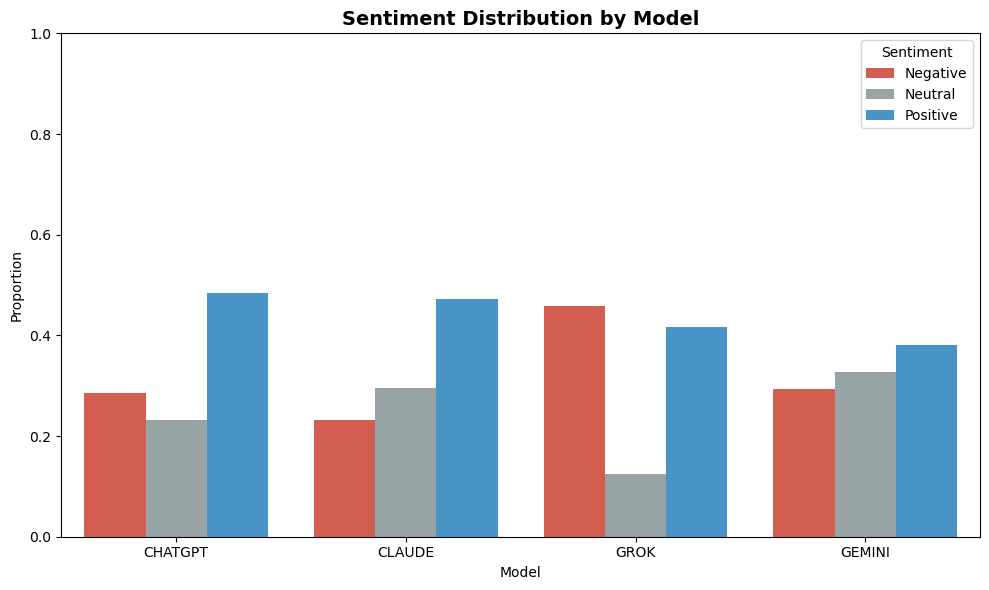

In [3]:
# Simple sentiment analysis visualization
sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
colors = ['#e74c3c', '#95a5a6', '#3498db']  # Red, Gray, Blue

# Calculate sentiment ratios (only when model is mentioned)
sentiment_data = []
for model in model_names:
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    if len(model_mentioned) > 0:
        ratios = model_mentioned[f'{model}_pred'].value_counts(normalize=True).sort_index()
        for sentiment_val in [-1, 0, 1]:
            ratio = ratios.get(sentiment_val, 0)
            sentiment_data.append({
                'Model': model.upper(),
                'Sentiment': sentiment_labels[sentiment_val],
                'Ratio': ratio
            })

sentiment_df = pd.DataFrame(sentiment_data)

# Simple bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=sentiment_df, x='Model', y='Ratio', hue='Sentiment', palette=colors)
plt.title('Sentiment Distribution by Model', fontsize=14, fontweight='bold')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

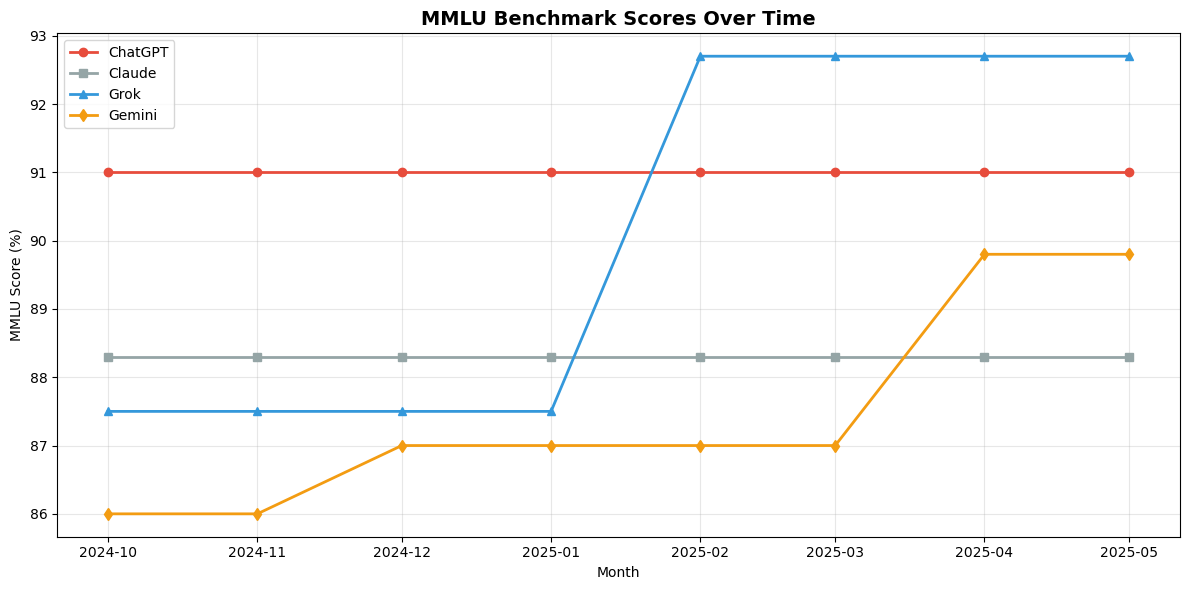

In [4]:
# Process benchmark and market share data
benchmark_df['Month'] = pd.to_datetime(benchmark_df['월'], format='%Y년 %m월')
for col in ['ChatGPT (OpenAI)', 'Claude (Anthropic)', 'Grok (xAI)', 'Gemini (Google)']:
    benchmark_df[col] = benchmark_df[col].str.replace('%', '').astype(float)

market_share_df['Month'] = pd.to_datetime(market_share_df['Month'], format='%B %Y')

# Simple benchmark visualization
plt.figure(figsize=(12, 6))
plt.plot(benchmark_df['Month'], benchmark_df['ChatGPT (OpenAI)'], 'o-', label='ChatGPT', color='#e74c3c', linewidth=2)
plt.plot(benchmark_df['Month'], benchmark_df['Claude (Anthropic)'], 's-', label='Claude', color='#95a5a6', linewidth=2)
plt.plot(benchmark_df['Month'], benchmark_df['Grok (xAI)'], '^-', label='Grok', color='#3498db', linewidth=2)
plt.plot(benchmark_df['Month'], benchmark_df['Gemini (Google)'], 'd-', label='Gemini', color='#f39c12', linewidth=2)

plt.title('MMLU Benchmark Scores Over Time', fontsize=14, fontweight='bold')
plt.ylabel('MMLU Score (%)')
plt.xlabel('Month')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Simple correlation analysis - create summary metrics
summary_data = []

for model in ['chatgpt', 'claude', 'gemini']:
    # Get sentiment data
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    if len(model_mentioned) > 0:
        monthly_sentiment = model_mentioned.groupby('Month')[f'{model}_pred'].apply(
            lambda x: (x == 1).sum() - (x == -1).sum()  # Net positive sentiment
        )

        # Get benchmark data
        if model == 'chatgpt':
            benchmark_scores = benchmark_df.set_index('Month')['ChatGPT (OpenAI)']
        elif model == 'claude':
            benchmark_scores = benchmark_df.set_index('Month')['Claude (Anthropic)']
        elif model == 'gemini':
            benchmark_scores = benchmark_df.set_index('Month')['Gemini (Google)']

        # Get market share data
        if model == 'chatgpt':
            market_shares = market_share_df.set_index('Month')['ChatGPT Market Share (%)']
        elif model == 'claude':
            market_shares = market_share_df.set_index('Month')['ClaudeAI Market Share (%)']
        elif model == 'gemini':
            market_shares = market_share_df.set_index('Month')['Gemini Market Share (%)']

        # Align data by month
        common_months = monthly_sentiment.index.intersection(benchmark_scores.index)
        if len(common_months) > 1:
            sentiment_corr = monthly_sentiment.reindex(common_months)
            benchmark_corr = benchmark_scores.reindex(common_months)

            # Calculate correlation
            if len(sentiment_corr) > 1 and sentiment_corr.std() > 0:
                corr_benchmark = sentiment_corr.corr(benchmark_corr)
                summary_data.append({
                    'Model': model.upper(),
                    'Metric': 'Benchmark',
                    'Correlation': corr_benchmark
                })

        # Market share correlation
        common_months_market = monthly_sentiment.index.intersection(market_shares.index)
        if len(common_months_market) > 1:
            sentiment_corr_market = monthly_sentiment.reindex(common_months_market)
            market_corr = market_shares.reindex(common_months_market)

            if len(sentiment_corr_market) > 1 and sentiment_corr_market.std() > 0:
                corr_market = sentiment_corr_market.corr(market_corr)
                summary_data.append({
                    'Model': model.upper(),
                    'Metric': 'Market Share',
                    'Correlation': corr_market
                })

# Simple correlation visualization
if summary_data:
    corr_df = pd.DataFrame(summary_data)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=corr_df, x='Model', y='Correlation', hue='Metric', palette=['#3498db', '#e74c3c'])
    plt.title('Correlation: Sentiment vs Performance Metrics', fontsize=14, fontweight='bold')
    plt.ylabel('Correlation Coefficient')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.ylim(-1, 1)
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.show()

    print("Correlation Summary:")
    for _, row in corr_df.iterrows():
        print(f"{row['Model']} - {row['Metric']}: {row['Correlation']:.3f}")
else:
    print("Insufficient data for correlation analysis")

Insufficient data for correlation analysis


In [6]:
# Summary insights
print("=== Key Insights ===")
print("\n1. Sentiment Distribution:")
for model in model_names:
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    if len(model_mentioned) > 0:
        positive = (model_mentioned[f'{model}_pred'] == 1).mean() * 100
        negative = (model_mentioned[f'{model}_pred'] == -1).mean() * 100
        neutral = (model_mentioned[f'{model}_pred'] == 0).mean() * 100
        print(f"  {model.upper()}: {positive:.1f}% positive, {negative:.1f}% negative, {neutral:.1f}% neutral")

print("\n2. Performance Metrics:")
print("  MMLU Benchmark (Latest):")
latest_benchmark = benchmark_df.iloc[-1]
for model_col in ['ChatGPT (OpenAI)', 'Claude (Anthropic)', 'Grok (xAI)', 'Gemini (Google)']:
    model_name = model_col.split(' ')[0]
    print(f"    {model_name}: {latest_benchmark[model_col]:.1f}%")

print("\n  Market Share (Latest):")
latest_market = market_share_df.iloc[-1]
for model_col in ['ChatGPT Market Share (%)', 'ClaudeAI Market Share (%)', 'Gemini Market Share (%)']:
    model_name = model_col.split(' ')[0]
    print(f"    {model_name}: {latest_market[model_col]:.1f}%")

print(f"\n3. Analysis based on {len(df):,} posts from {df['Timestamp'].min().date()} to {df['Timestamp'].max().date()}")

=== Key Insights ===

1. Sentiment Distribution:
  CHATGPT: 48.4% positive, 28.5% negative, 23.1% neutral
  CLAUDE: 47.1% positive, 23.3% negative, 29.6% neutral
  GROK: 41.6% positive, 45.9% negative, 12.5% neutral
  GEMINI: 38.0% positive, 29.3% negative, 32.7% neutral

2. Performance Metrics:
  MMLU Benchmark (Latest):
    ChatGPT: 91.0%
    Claude: 88.3%
    Grok: 92.7%
    Gemini: 89.8%

  Market Share (Latest):
    ChatGPT: 74.9%
    ClaudeAI: 3.2%
    Gemini: 13.4%

3. Analysis based on 20,176 posts from 2024-11-03 to 2025-06-20


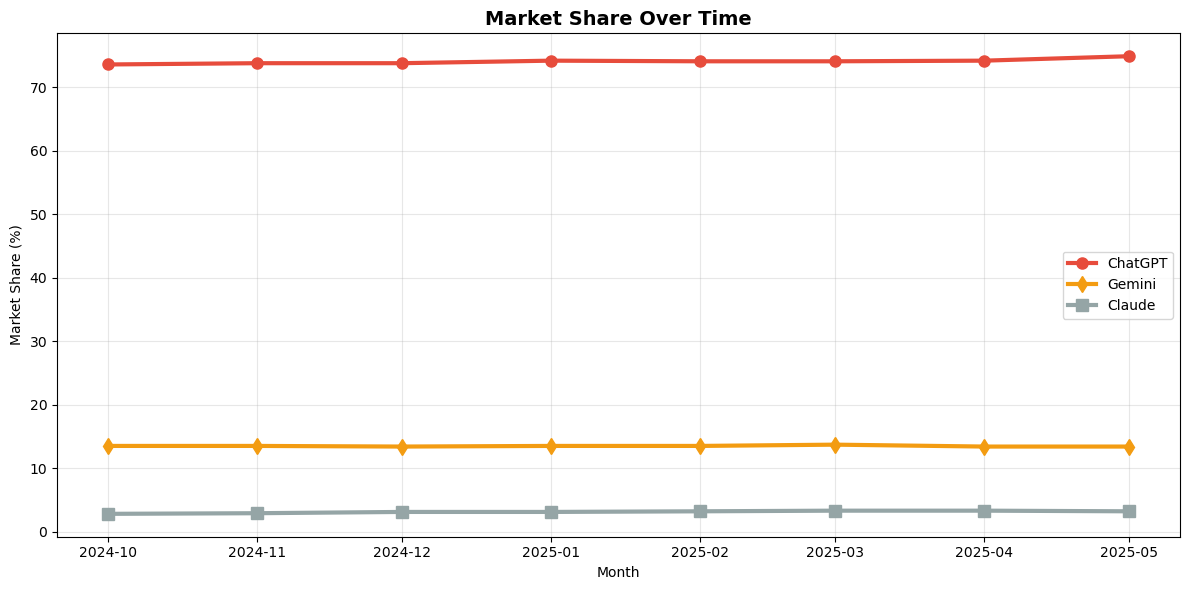

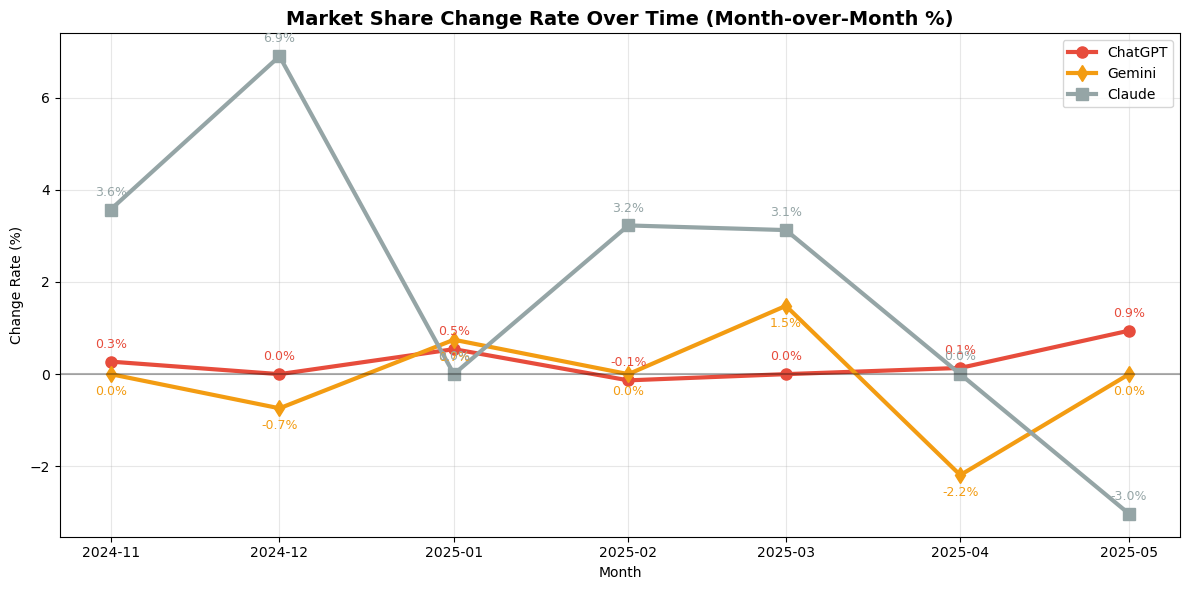

In [16]:
# Market share change rate visualization
market_share_change = market_share_df.copy()

# Calculate month-over-month change rates
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100

# Remove first row (NaN from pct_change)
market_share_change = market_share_change.dropna()

plt.figure(figsize=(12, 6))
plt.plot(market_share_change['Month'], market_share_change['ChatGPT_Change'], 'o-',
         label='ChatGPT', color='#e74c3c', linewidth=3, markersize=8)
plt.plot(market_share_change['Month'], market_share_change['Gemini_Change'], 'd-',
         label='Gemini', color='#f39c12', linewidth=3, markersize=8)
plt.plot(market_share_change['Month'], market_share_change['Claude_Change'], 's-',
         label='Claude', color='#95a5a6', linewidth=3, markersize=8)

plt.title('Market Share Change Rate Over Time (Month-over-Month %)', fontsize=14, fontweight='bold')
plt.ylabel('Change Rate (%)')
plt.xlabel('Month')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)  # Reference line at 0%
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels on points
for month, chatgpt_change in zip(market_share_change['Month'], market_share_change['ChatGPT_Change']):
    plt.annotate(f'{chatgpt_change:.1f}%', (month, chatgpt_change),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='#e74c3c')

for month, gemini_change in zip(market_share_change['Month'], market_share_change['Gemini_Change']):
    plt.annotate(f'{gemini_change:.1f}%', (month, gemini_change),
                textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='#f39c12')

for month, claude_change in zip(market_share_change['Month'], market_share_change['Claude_Change']):
    plt.annotate(f'{claude_change:.1f}%', (month, claude_change),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='#95a5a6')

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


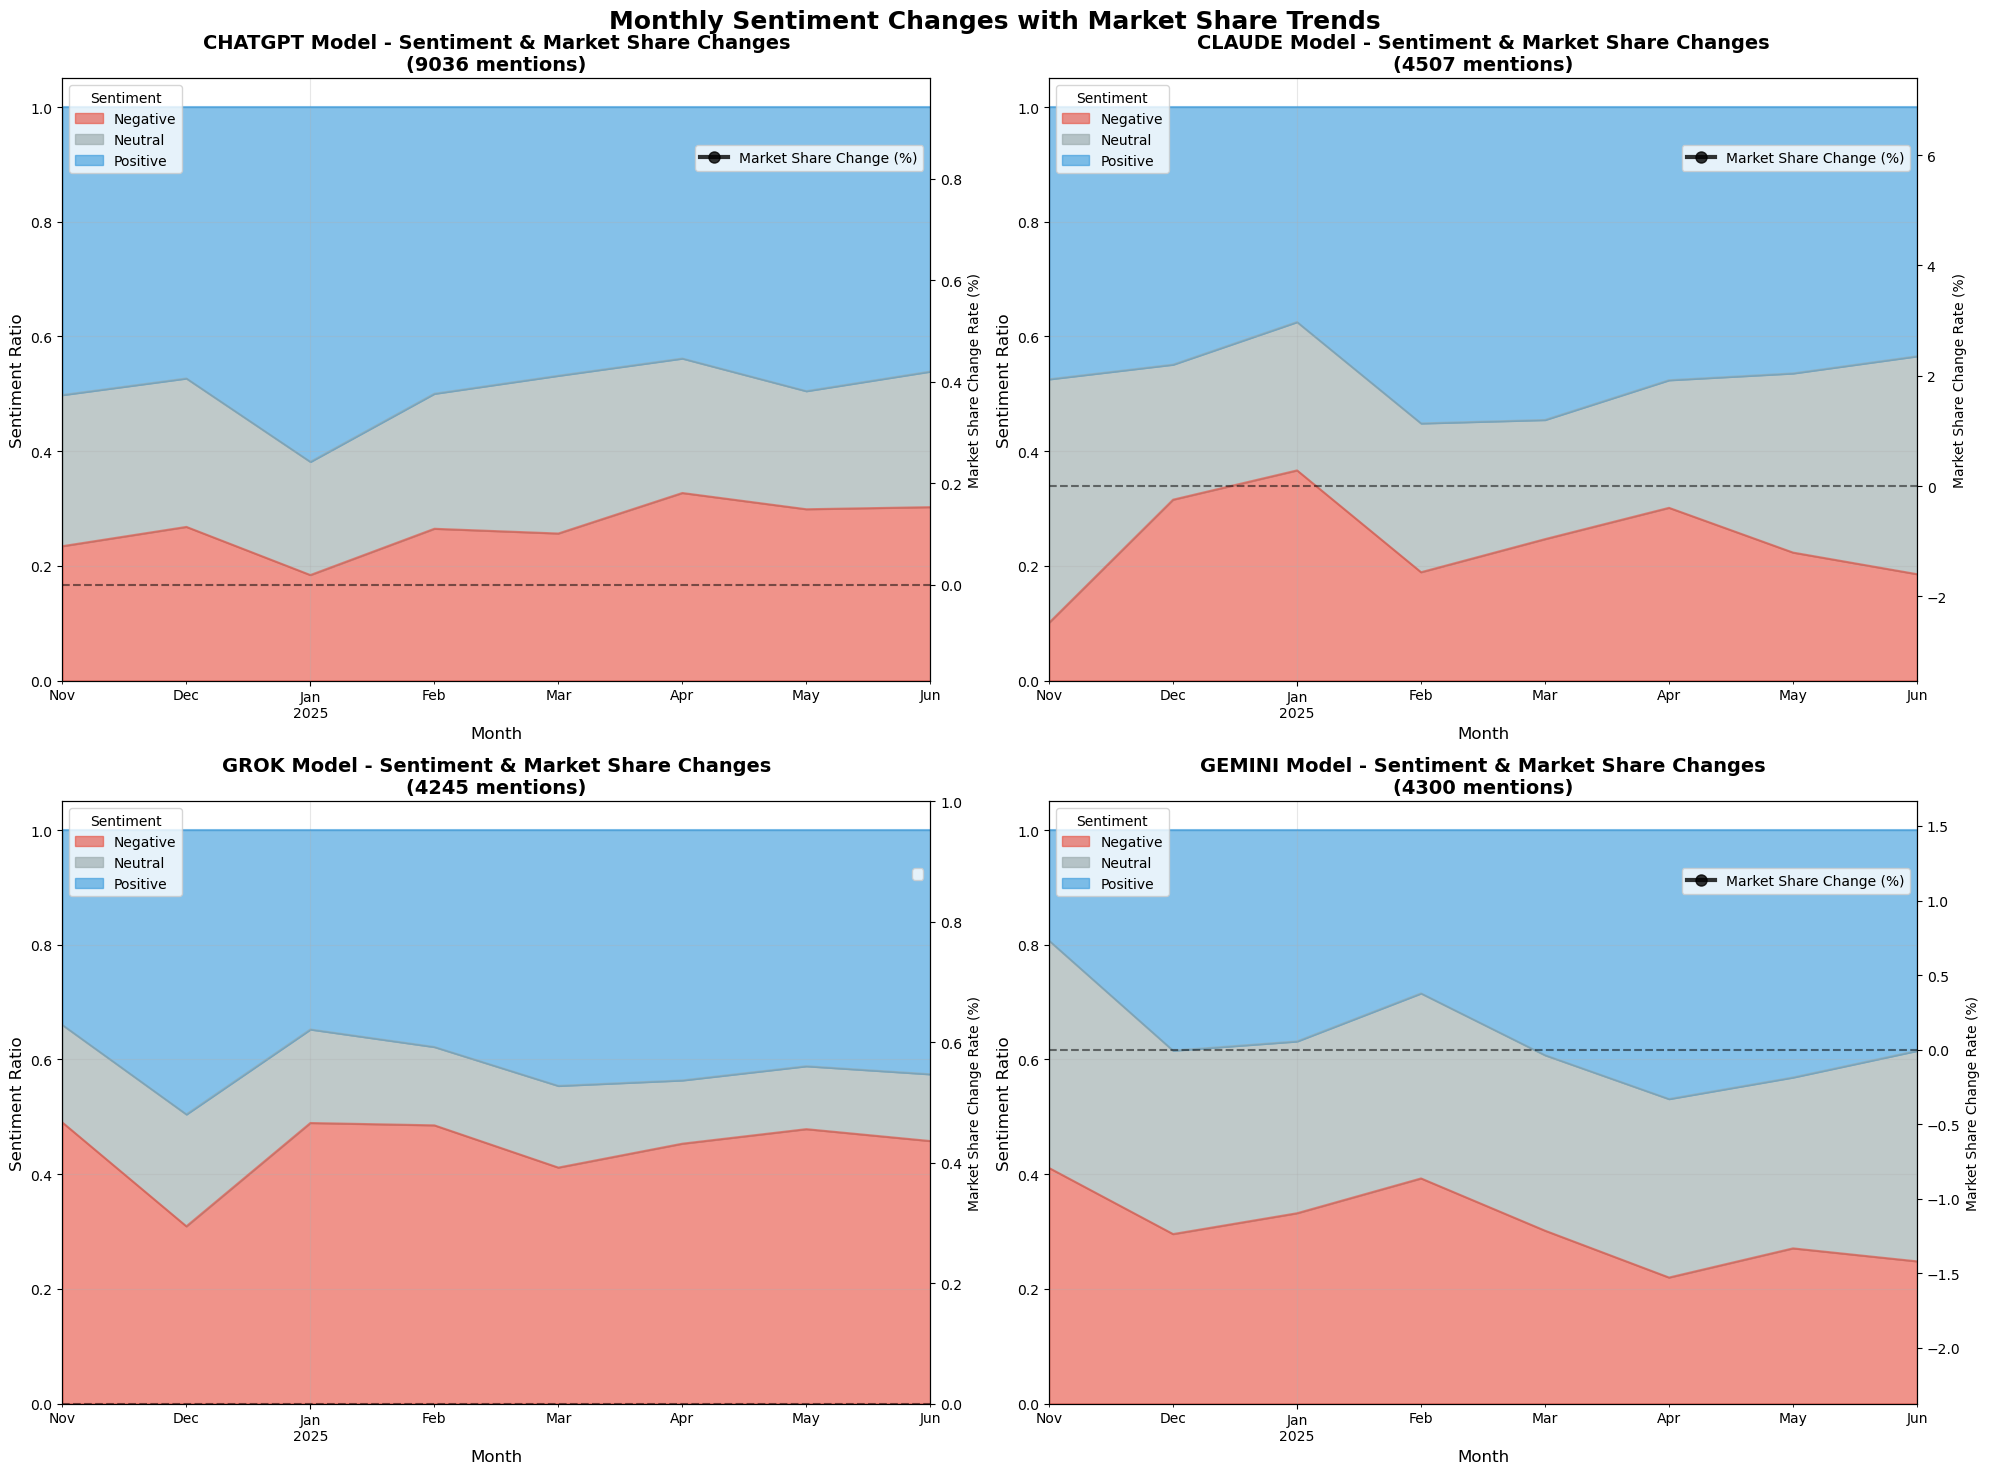

In [10]:
# Combined sentiment and market share visualization by model
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Monthly Sentiment Changes with Market Share Trends', fontsize=18, fontweight='bold')

# Prepare market share change data
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

for i, model in enumerate(model_names):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]

    if len(model_mentioned) > 0:
        # Calculate monthly sentiment distribution
        monthly_sentiment = model_mentioned.groupby(['Month', f'{model}_pred']).size().unstack(fill_value=0)
        monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

        # Rename columns
        sentiment_columns = {}
        for col in monthly_sentiment_pct.columns:
            if col in sentiment_labels:
                sentiment_columns[col] = sentiment_labels[col]
        monthly_sentiment_pct = monthly_sentiment_pct.rename(columns=sentiment_columns)

        # Stacked area chart for sentiment
        monthly_sentiment_pct.plot(kind='area', ax=ax, alpha=0.6,
                                  color=['#e74c3c', '#95a5a6', '#3498db'])

        # Add market share change rate line (secondary y-axis)
        ax2 = ax.twinx()

        # Plot market share change for the specific model
        if model == 'chatgpt' and 'ChatGPT_Change' in market_share_change.columns:
            ax2.plot(market_share_change['Month'], market_share_change['ChatGPT_Change'],
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share Change (%)')
        elif model == 'claude' and 'Claude_Change' in market_share_change.columns:
            ax2.plot(market_share_change['Month'], market_share_change['Claude_Change'],
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share Change (%)')
        elif model == 'gemini' and 'Gemini_Change' in market_share_change.columns:
            ax2.plot(market_share_change['Month'], market_share_change['Gemini_Change'],
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share Change (%)')

        ax.set_title(f'{model.upper()} Model - Sentiment & Market Share Changes\n({len(model_mentioned)} mentions)',
                    fontsize=14, fontweight='bold')
        ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax2.set_ylabel('Market Share Change Rate (%)', fontsize=10)
        ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.9))

    else:
        ax.set_title(f'{model.upper()} Model - No mentions found', fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=16)

    ax.set_ylabel('Sentiment Ratio', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left')

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Check market share data changes
print("Market Share Data Overview:")
print(market_share_df)
print("\nMarket Share Changes:")
print("ChatGPT:", market_share_df['ChatGPT Market Share (%)'].min(), "→", market_share_df['ChatGPT Market Share (%)'].max())
print("Claude:", market_share_df['ClaudeAI Market Share (%)'].min(), "→", market_share_df['ClaudeAI Market Share (%)'].max())
print("Gemini:", market_share_df['Gemini Market Share (%)'].min(), "→", market_share_df['Gemini Market Share (%)'].max())

print("\nMonth-over-Month Change Rates:")
changes = market_share_df.copy()
changes['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
changes['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
changes['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
print(changes[['Month', 'ChatGPT_Change', 'Claude_Change', 'Gemini_Change']].dropna())

Market Share Data Overview:
       Month  ChatGPT Market Share (%)  Gemini Market Share (%)  \
0 2024-10-01                      73.6                     13.5   
1 2024-11-01                      73.8                     13.5   
2 2024-12-01                      73.8                     13.4   
3 2025-01-01                      74.2                     13.5   
4 2025-02-01                      74.1                     13.5   
5 2025-03-01                      74.1                     13.7   
6 2025-04-01                      74.2                     13.4   
7 2025-05-01                      74.9                     13.4   

   ClaudeAI Market Share (%)  
0                        2.8  
1                        2.9  
2                        3.1  
3                        3.1  
4                        3.2  
5                        3.3  
6                        3.3  
7                        3.2  

Market Share Changes:
ChatGPT: 73.6 → 74.9
Claude: 2.8 → 3.3
Gemini: 13.4 → 13.7

Month-

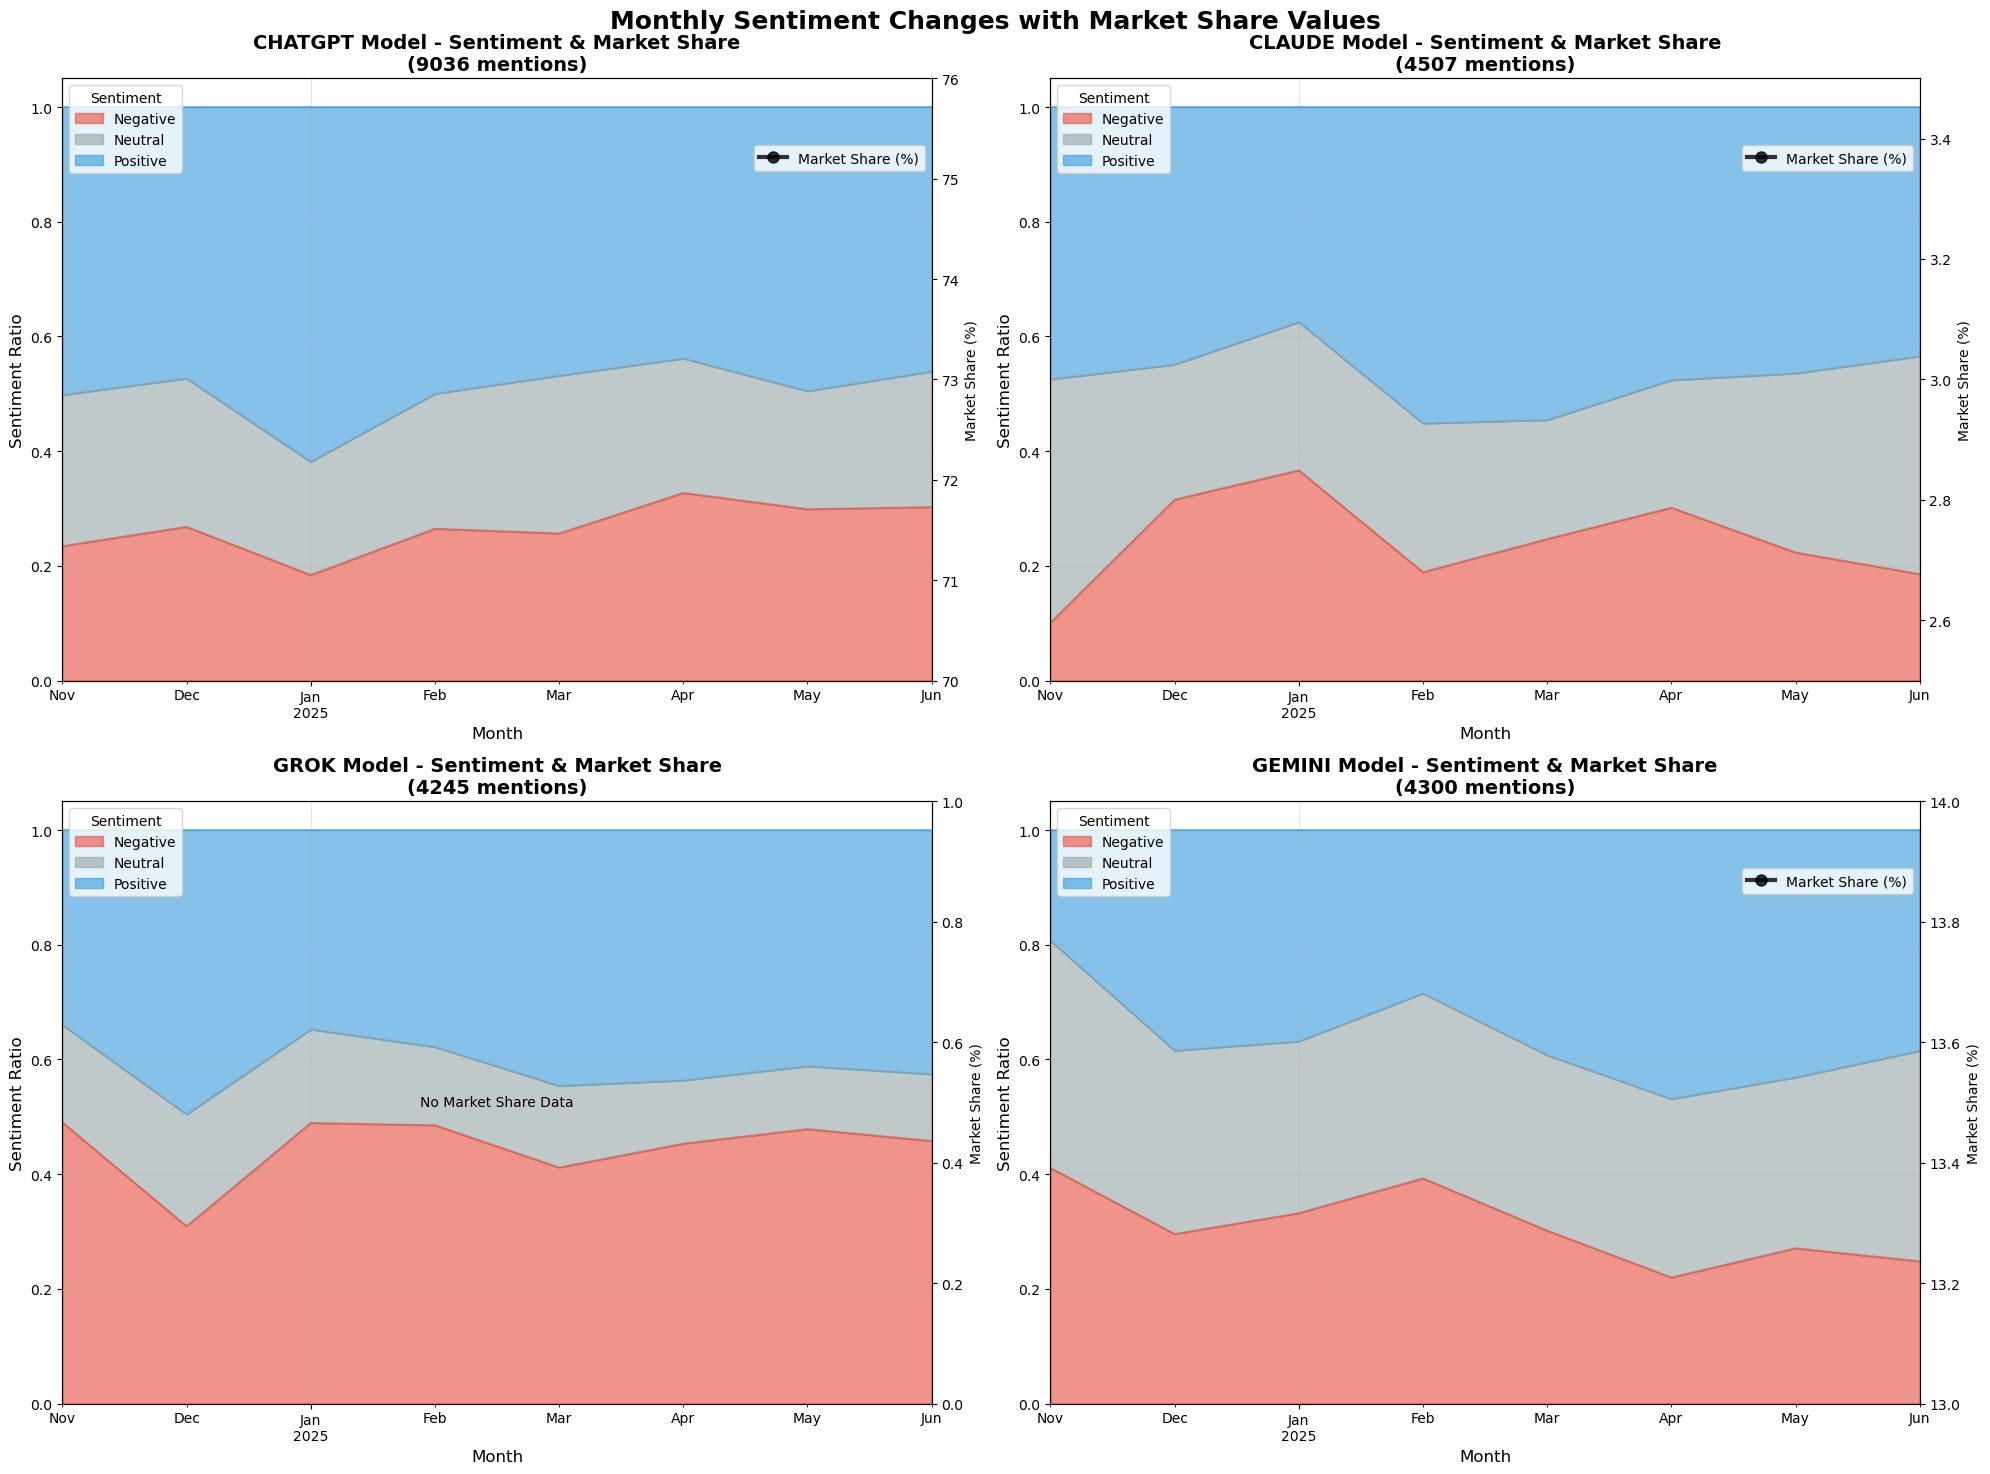

In [12]:
# Alternative: Use absolute market share values instead of change rates
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Monthly Sentiment Changes with Market Share Values', fontsize=18, fontweight='bold')

sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

for i, model in enumerate(model_names):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]

    if len(model_mentioned) > 0:
        # Calculate monthly sentiment distribution
        monthly_sentiment = model_mentioned.groupby(['Month', f'{model}_pred']).size().unstack(fill_value=0)
        monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

        # Rename columns
        sentiment_columns = {}
        for col in monthly_sentiment_pct.columns:
            if col in sentiment_labels:
                sentiment_columns[col] = sentiment_labels[col]
        monthly_sentiment_pct = monthly_sentiment_pct.rename(columns=sentiment_columns)

        # Stacked area chart for sentiment
        monthly_sentiment_pct.plot(kind='area', ax=ax, alpha=0.6,
                                  color=['#e74c3c', '#95a5a6', '#3498db'])

        # Add market share absolute values (secondary y-axis)
        ax2 = ax.twinx()

        # Plot market share absolute values for the specific model
        if model == 'chatgpt':
            ax2.plot(market_share_df['Month'], market_share_df['ChatGPT Market Share (%)'],
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share (%)')
            ax2.set_ylim(70, 76)  # Focus on the actual range
        elif model == 'claude':
            ax2.plot(market_share_df['Month'], market_share_df['ClaudeAI Market Share (%)'],
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share (%)')
            ax2.set_ylim(2.5, 3.5)  # Focus on the actual range
        elif model == 'gemini':
            ax2.plot(market_share_df['Month'], market_share_df['Gemini Market Share (%)'],
                    'ko-', linewidth=3, markersize=8, alpha=0.8, label='Market Share (%)')
            ax2.set_ylim(13, 14)  # Focus on the actual range
        elif model == 'grok':
            # No market share data for Grok
            ax2.text(0.5, 0.5, 'No Market Share Data', ha='center', va='center', transform=ax2.transAxes)

        ax.set_title(f'{model.upper()} Model - Sentiment & Market Share\n({len(model_mentioned)} mentions)',
                    fontsize=14, fontweight='bold')
        ax2.set_ylabel('Market Share (%)', fontsize=10)
        if model != 'grok':
            ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.9))

    else:
        ax.set_title(f'{model.upper()} Model - No mentions found', fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=16)

    ax.set_ylabel('Sentiment Ratio', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Market Share Point Changes:
       Month  ChatGPT_Point_Change  Claude_Point_Change  Gemini_Point_Change
1 2024-11-01                   0.2                  0.1                  0.0
2 2024-12-01                   0.0                  0.2                 -0.1
3 2025-01-01                   0.4                  0.0                  0.1
4 2025-02-01                  -0.1                  0.1                  0.0
5 2025-03-01                   0.0                  0.1                  0.2
6 2025-04-01                   0.1                  0.0                 -0.3
7 2025-05-01                   0.7                 -0.1                  0.0


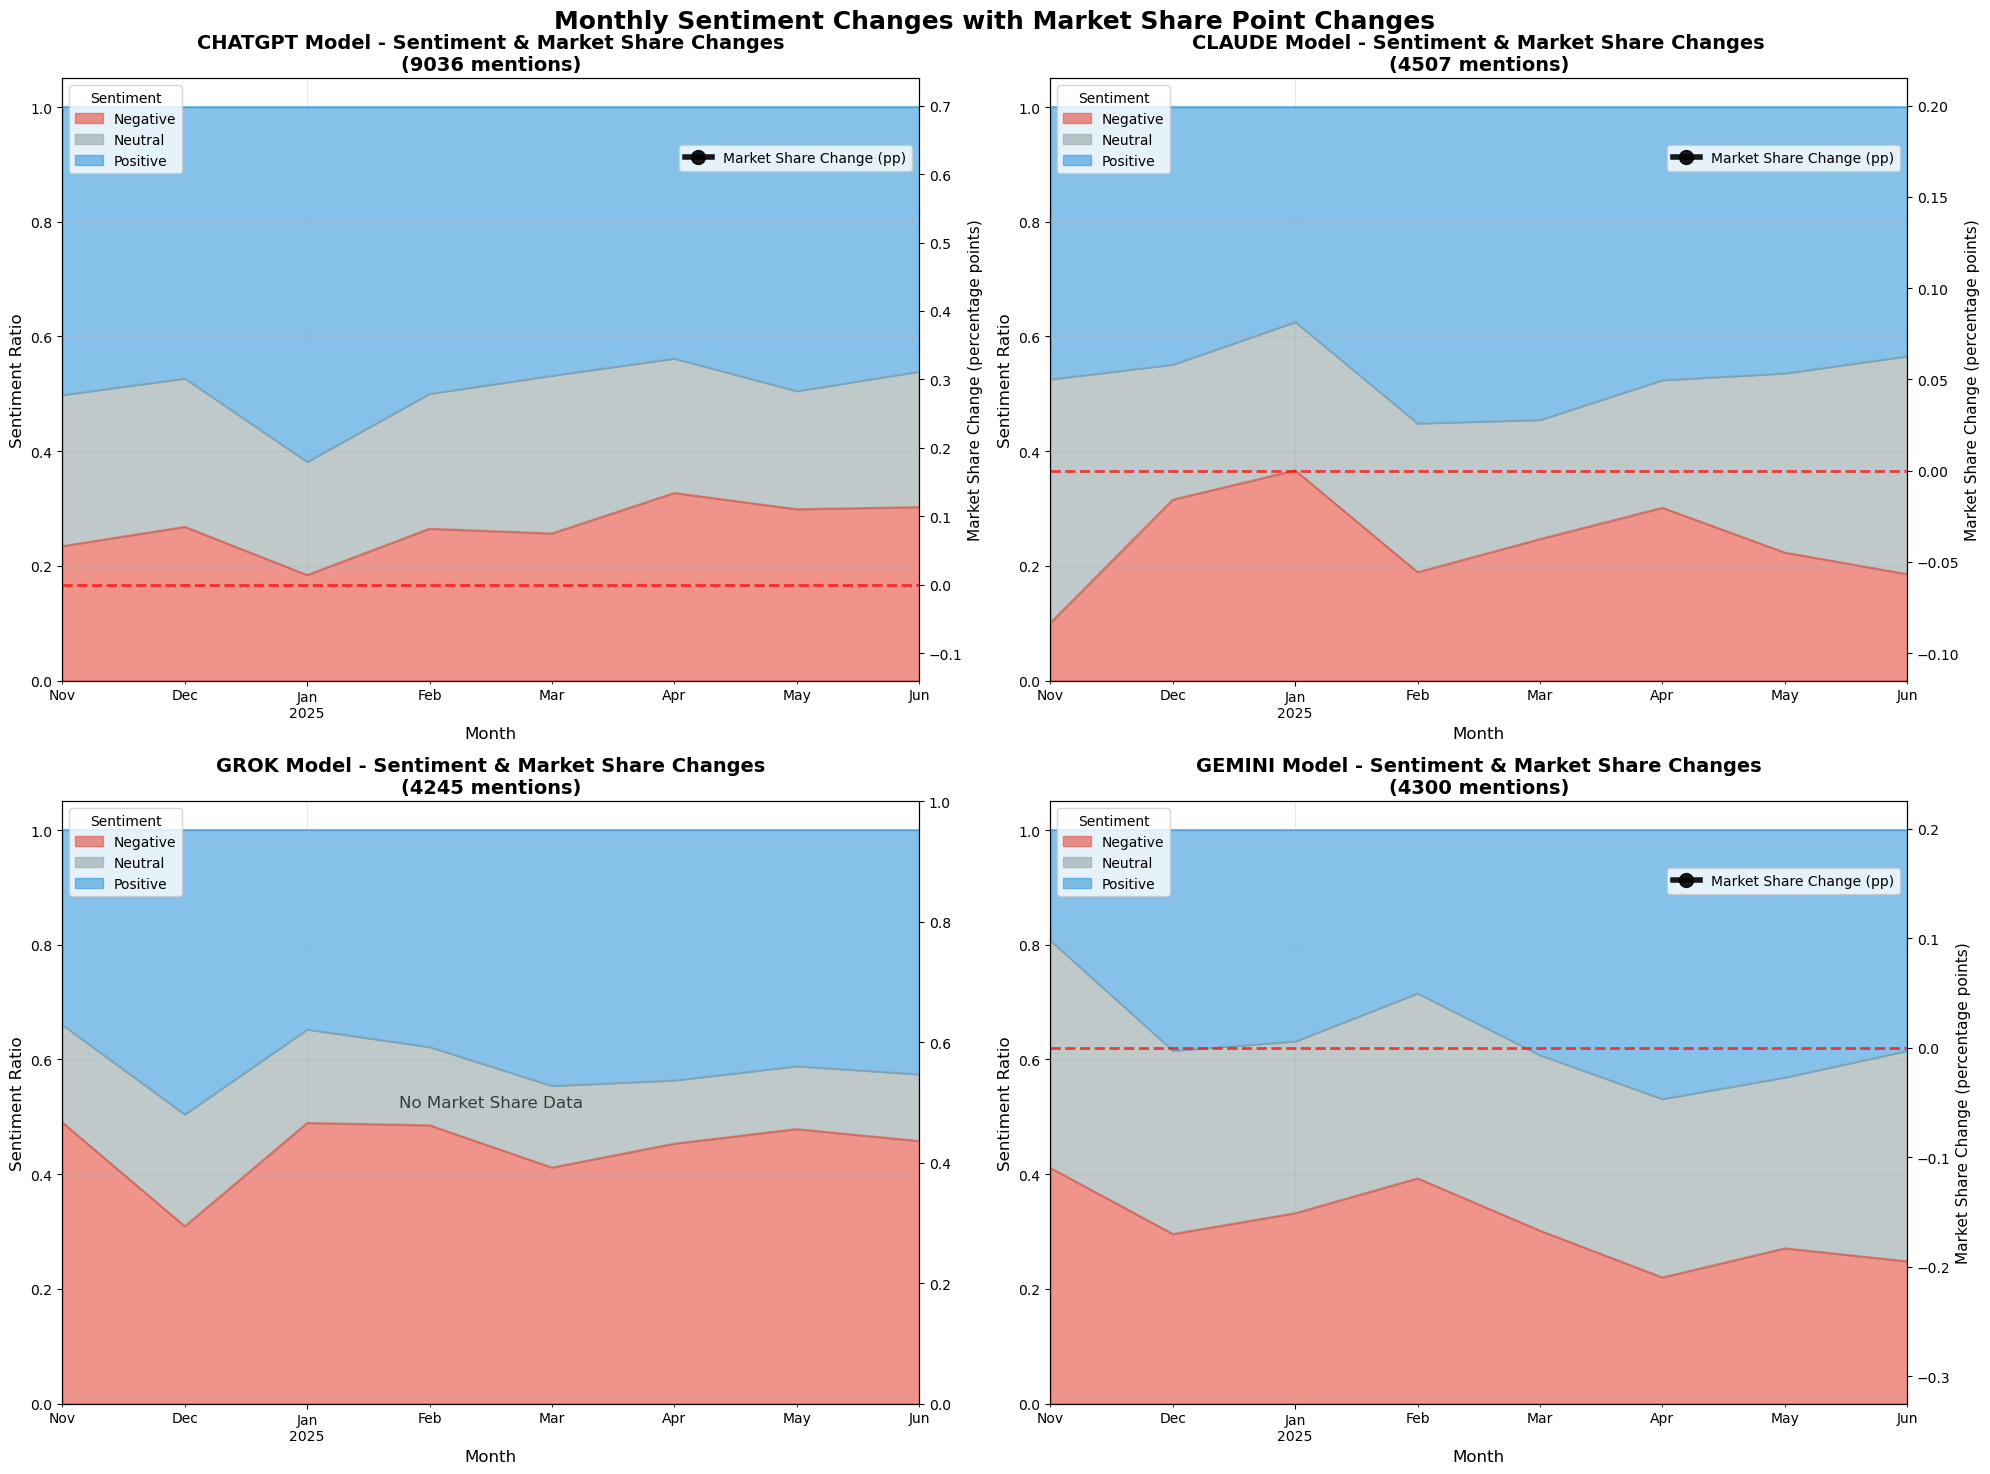

In [13]:
# Use absolute point changes in market share (percentage points)
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Monthly Sentiment Changes with Market Share Point Changes', fontsize=18, fontweight='bold')

# Calculate absolute point changes (not percentage changes)
market_share_point_change = market_share_df.copy()
market_share_point_change['ChatGPT_Point_Change'] = market_share_df['ChatGPT Market Share (%)'].diff()
market_share_point_change['Gemini_Point_Change'] = market_share_df['Gemini Market Share (%)'].diff()
market_share_point_change['Claude_Point_Change'] = market_share_df['ClaudeAI Market Share (%)'].diff()
market_share_point_change = market_share_point_change.dropna()

print("Market Share Point Changes:")
print(market_share_point_change[['Month', 'ChatGPT_Point_Change', 'Claude_Point_Change', 'Gemini_Point_Change']])

sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

for i, model in enumerate(model_names):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]

    if len(model_mentioned) > 0:
        # Calculate monthly sentiment distribution
        monthly_sentiment = model_mentioned.groupby(['Month', f'{model}_pred']).size().unstack(fill_value=0)
        monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

        # Rename columns
        sentiment_columns = {}
        for col in monthly_sentiment_pct.columns:
            if col in sentiment_labels:
                sentiment_columns[col] = sentiment_labels[col]
        monthly_sentiment_pct = monthly_sentiment_pct.rename(columns=sentiment_columns)

        # Stacked area chart for sentiment
        monthly_sentiment_pct.plot(kind='area', ax=ax, alpha=0.6,
                                  color=['#e74c3c', '#95a5a6', '#3498db'])

        # Add market share point changes (secondary y-axis)
        ax2 = ax.twinx()

        # Plot market share point changes for the specific model
        if model == 'chatgpt':
            ax2.plot(market_share_point_change['Month'], market_share_point_change['ChatGPT_Point_Change'],
                    'ko-', linewidth=4, markersize=10, alpha=0.9, label='Market Share Change (pp)')
            # Add value labels
            for month, change in zip(market_share_point_change['Month'], market_share_point_change['ChatGPT_Point_Change']):
                ax2.annotate(f'{change:.1f}pp', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center', fontsize=10,
                            color='black', fontweight='bold')
        elif model == 'claude':
            ax2.plot(market_share_point_change['Month'], market_share_point_change['Claude_Point_Change'],
                    'ko-', linewidth=4, markersize=10, alpha=0.9, label='Market Share Change (pp)')
            # Add value labels
            for month, change in zip(market_share_point_change['Month'], market_share_point_change['Claude_Point_Change']):
                ax2.annotate(f'{change:.1f}pp', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center', fontsize=10,
                            color='black', fontweight='bold')
        elif model == 'gemini':
            ax2.plot(market_share_point_change['Month'], market_share_point_change['Gemini_Point_Change'],
                    'ko-', linewidth=4, markersize=10, alpha=0.9, label='Market Share Change (pp)')
            # Add value labels
            for month, change in zip(market_share_point_change['Month'], market_share_point_change['Gemini_Point_Change']):
                ax2.annotate(f'{change:.1f}pp', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center', fontsize=10,
                            color='black', fontweight='bold')
        elif model == 'grok':
            # No market share data for Grok
            ax2.text(0.5, 0.5, 'No Market Share Data', ha='center', va='center',
                    transform=ax2.transAxes, fontsize=12, alpha=0.7)

        # Add horizontal line at 0
        if model != 'grok':
            ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
            ax2.set_ylabel('Market Share Change (percentage points)', fontsize=11)
            ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.9))

        ax.set_title(f'{model.upper()} Model - Sentiment & Market Share Changes\n({len(model_mentioned)} mentions)',
                    fontsize=14, fontweight='bold')

    else:
        ax.set_title(f'{model.upper()} Model - No mentions found', fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=16)

    ax.set_ylabel('Sentiment Ratio', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'max'

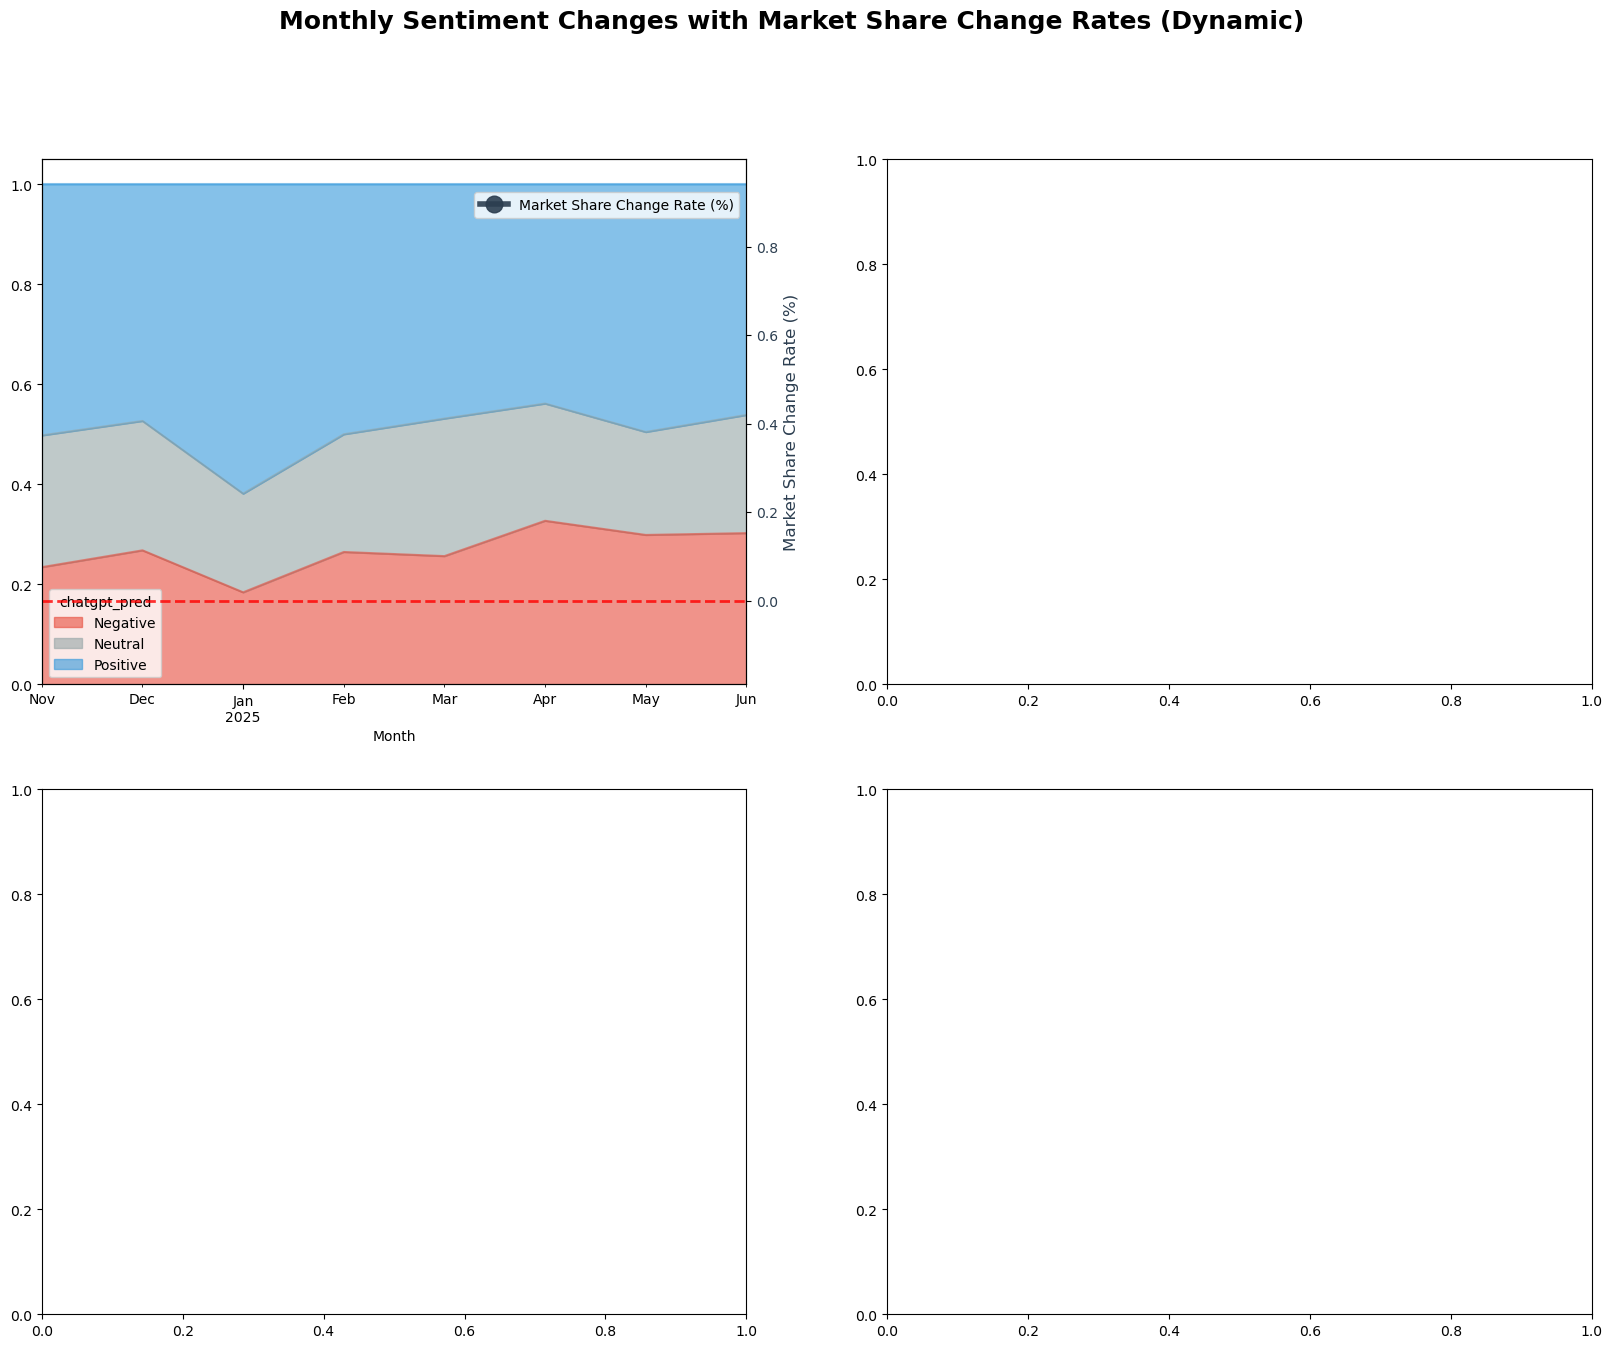

In [14]:
# Dynamic visualization: Sentiment changes with Market Share change rates
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Monthly Sentiment Changes with Market Share Change Rates (Dynamic)', fontsize=18, fontweight='bold')

# Calculate market share change rates
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

for i, model in enumerate(model_names):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]

    if len(model_mentioned) > 0:
        # Calculate monthly sentiment distribution
        monthly_sentiment = model_mentioned.groupby(['Month', f'{model}_pred']).size().unstack(fill_value=0)
        monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

        # Rename columns
        sentiment_columns = {}
        for col in monthly_sentiment_pct.columns:
            if col in sentiment_labels:
                sentiment_columns[col] = sentiment_labels[col]
        monthly_sentiment_pct = monthly_sentiment_pct.rename(columns=sentiment_columns)

        # Stacked area chart for sentiment
        monthly_sentiment_pct.plot(kind='area', ax=ax, alpha=0.6,
                                  color=['#e74c3c', '#95a5a6', '#3498db'])

        # Add market share change rate line (secondary y-axis)
        ax2 = ax.twinx()

        # Plot market share change rates with distinctive styling
        if model == 'chatgpt':
            ax2.plot(market_share_change['Month'], market_share_change['ChatGPT_Change'],
                    'o-', linewidth=4, markersize=12, alpha=0.9, color='#2c3e50',
                    label='Market Share Change Rate (%)')
            # Add value labels
            for month, change in zip(market_share_change['Month'], market_share_change['ChatGPT_Change']):
                ax2.annotate(f'{change:.1f}%', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center',
                            fontsize=10, color='#2c3e50', fontweight='bold')
        elif model == 'claude':
            ax2.plot(market_share_change['Month'], market_share_change['Claude_Change'],
                    's-', linewidth=4, markersize=12, alpha=0.9, color='#2c3e50',
                    label='Market Share Change Rate (%)')
            # Add value labels
            for month, change in zip(market_share_change['Month'], market_share_change['Claude_Change']):
                ax2.annotate(f'{change:.1f}%', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center',
                            fontsize=10, color='#2c3e50', fontweight='bold')
        elif model == 'gemini':
            ax2.plot(market_share_change['Month'], market_share_change['Gemini_Change'],
                    'd-', linewidth=4, markersize=12, alpha=0.9, color='#2c3e50',
                    label='Market Share Change Rate (%)')
            # Add value labels
            for month, change in zip(market_share_change['Month'], market_share_change['Gemini_Change']):
                ax2.annotate(f'{change:.1f}%', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center',
                            fontsize=10, color='#2c3e50', fontweight='bold')
        elif model == 'grok':
            # No market share data for Grok
            ax2.text(0.5, 0.5, 'No Market Share Data', ha='center', va='center',
                    transform=ax2.transAxes, fontsize=12, alpha=0.7, color='#7f8c8d')

        # Styling for market share change
        if model != 'grok':
            ax2.axhline(y=0, color='red', linestyle='--', alpha=0.8, linewidth=2)
            ax2.set_ylabel('Market Share Change Rate (%)', fontsize=12, color='#2c3e50')
            ax2.tick_params(axis='y', labelcolor='#2c3e50')
            ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.95))
            # Set y-axis limits to make changes more visible
            y_values = market_share_change[f'{model.title()}_Change'] if f'{model.title()}_Change' in market_share_change.columns else [0]
            if len(y_values) > 0:
                y_range = max(abs(y_values.max()), abs(y_values.min())) * 1.2
                ax2.set_ylim(-y_range, y_range)

        ax.set_title(f'{model.upper()} Model - Sentiment & Market Share Change Rate\n({len(model_mentioned)} mentions)',
                    fontsize=14, fontweight='bold')

    else:
        ax.set_title(f'{model.upper()} Model - No mentions found', fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=16)

    ax.set_ylabel('Sentiment Ratio', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

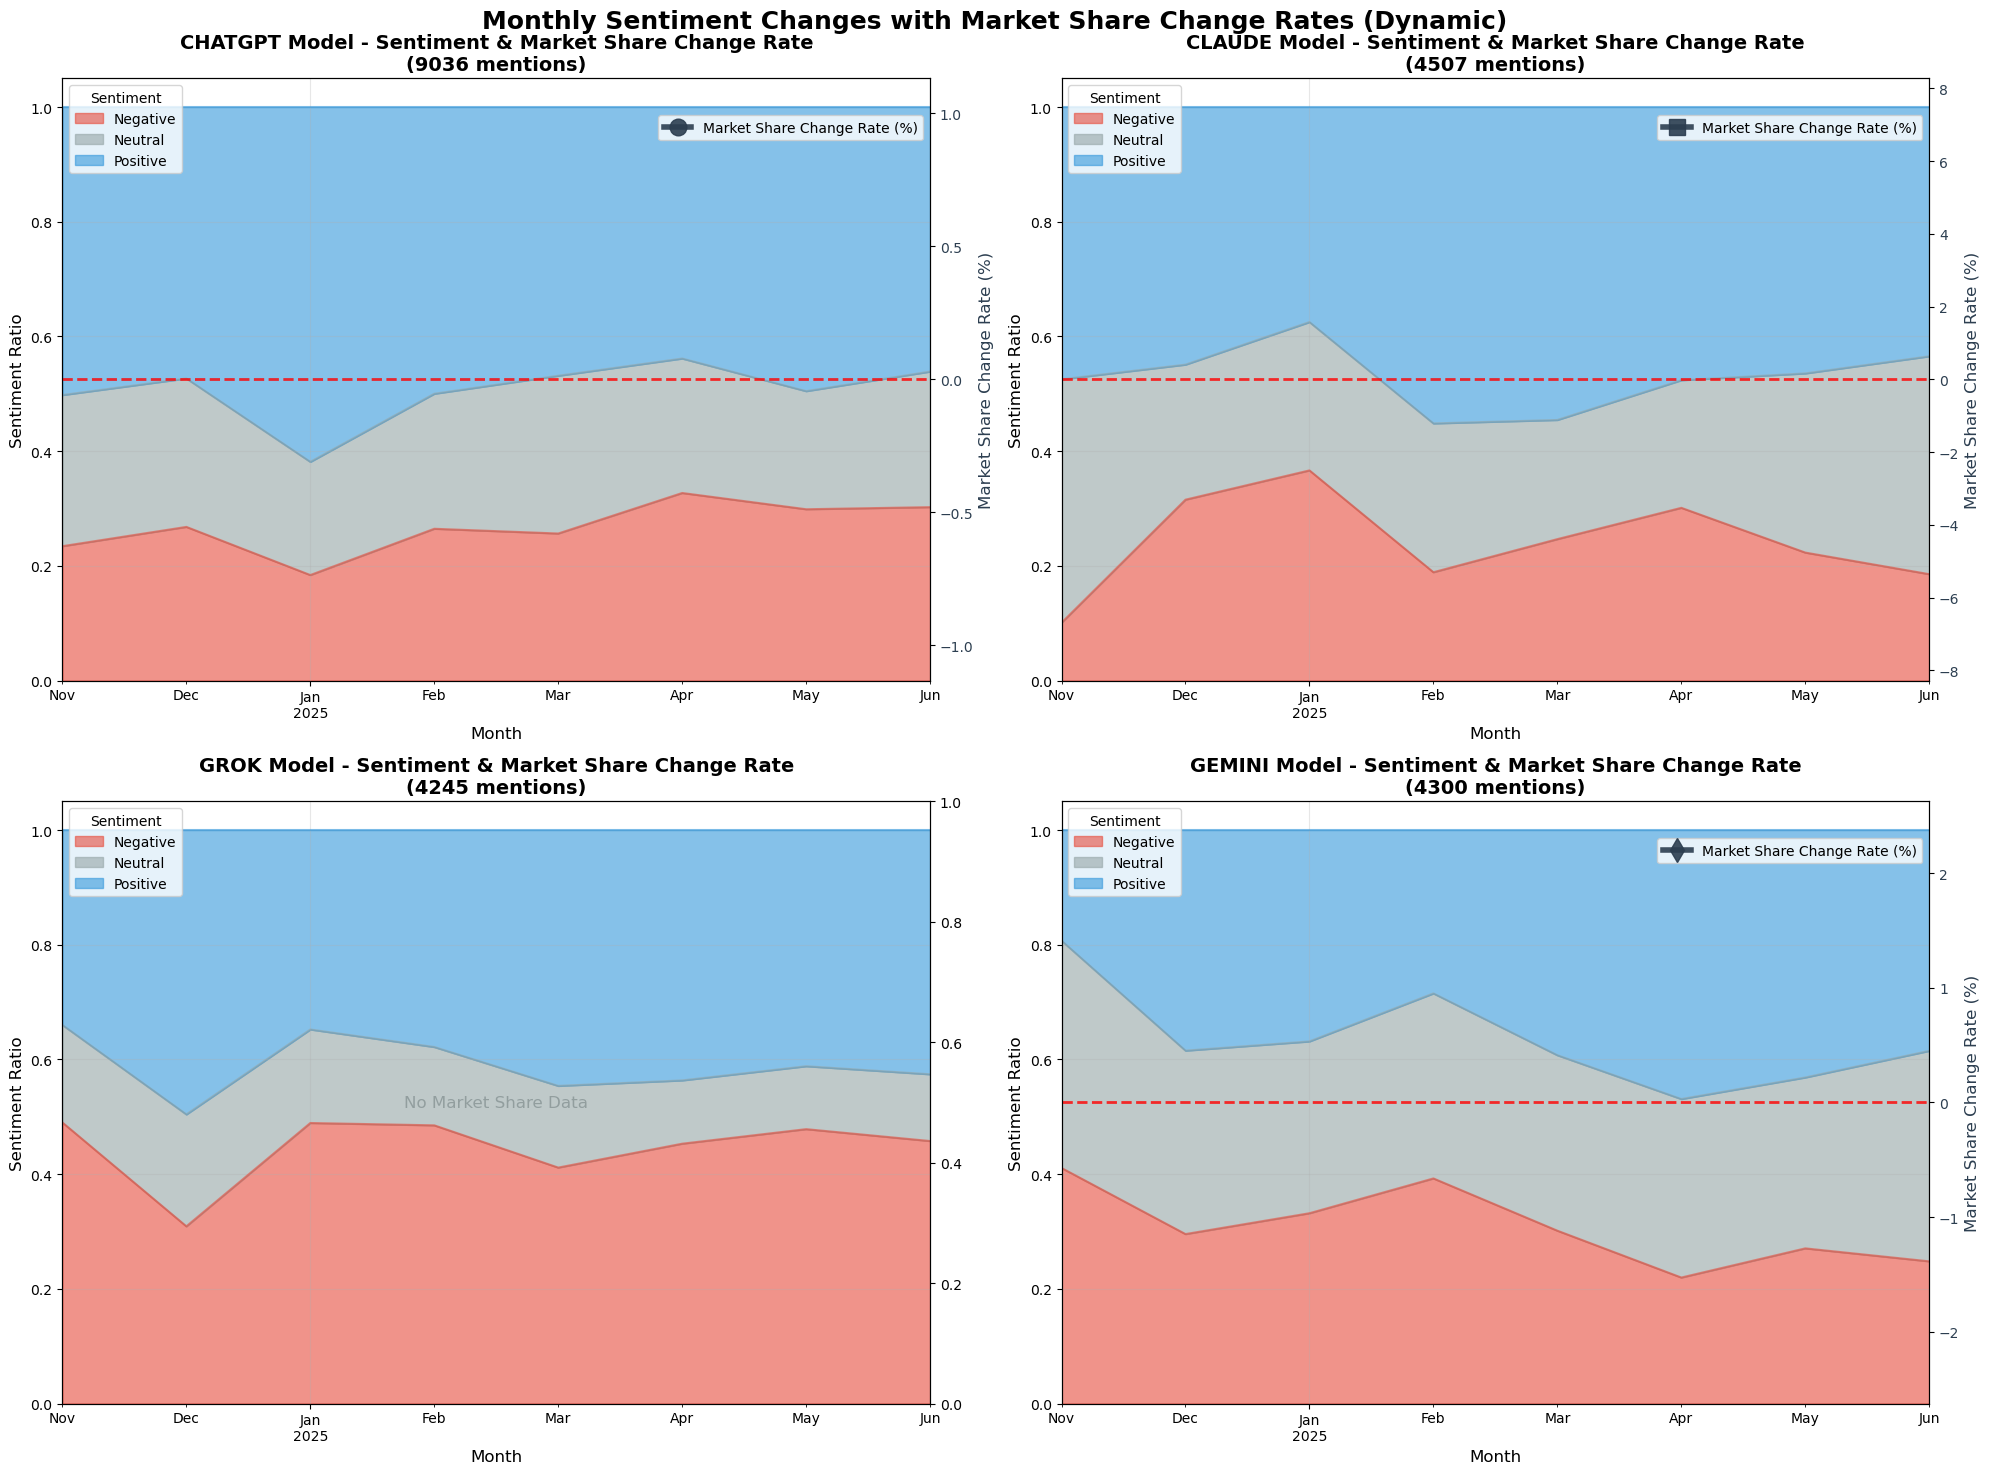

In [15]:
# Dynamic visualization: Sentiment changes with Market Share change rates
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Monthly Sentiment Changes with Market Share Change Rates (Dynamic)', fontsize=18, fontweight='bold')

# Calculate market share change rates
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

for i, model in enumerate(model_names):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]

    if len(model_mentioned) > 0:
        # Calculate monthly sentiment distribution
        monthly_sentiment = model_mentioned.groupby(['Month', f'{model}_pred']).size().unstack(fill_value=0)
        monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

        # Rename columns
        sentiment_columns = {}
        for col in monthly_sentiment_pct.columns:
            if col in sentiment_labels:
                sentiment_columns[col] = sentiment_labels[col]
        monthly_sentiment_pct = monthly_sentiment_pct.rename(columns=sentiment_columns)

        # Stacked area chart for sentiment
        monthly_sentiment_pct.plot(kind='area', ax=ax, alpha=0.6,
                                  color=['#e74c3c', '#95a5a6', '#3498db'])

        # Add market share change rate line (secondary y-axis)
        ax2 = ax.twinx()

        # Plot market share change rates with distinctive styling
        if model == 'chatgpt':
            ax2.plot(market_share_change['Month'], market_share_change['ChatGPT_Change'],
                    'o-', linewidth=4, markersize=12, alpha=0.9, color='#2c3e50',
                    label='Market Share Change Rate (%)')
            # Add value labels
            for month, change in zip(market_share_change['Month'], market_share_change['ChatGPT_Change']):
                ax2.annotate(f'{change:.1f}%', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center',
                            fontsize=10, color='#2c3e50', fontweight='bold')
            y_values = market_share_change['ChatGPT_Change']
        elif model == 'claude':
            ax2.plot(market_share_change['Month'], market_share_change['Claude_Change'],
                    's-', linewidth=4, markersize=12, alpha=0.9, color='#2c3e50',
                    label='Market Share Change Rate (%)')
            # Add value labels
            for month, change in zip(market_share_change['Month'], market_share_change['Claude_Change']):
                ax2.annotate(f'{change:.1f}%', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center',
                            fontsize=10, color='#2c3e50', fontweight='bold')
            y_values = market_share_change['Claude_Change']
        elif model == 'gemini':
            ax2.plot(market_share_change['Month'], market_share_change['Gemini_Change'],
                    'd-', linewidth=4, markersize=12, alpha=0.9, color='#2c3e50',
                    label='Market Share Change Rate (%)')
            # Add value labels
            for month, change in zip(market_share_change['Month'], market_share_change['Gemini_Change']):
                ax2.annotate(f'{change:.1f}%', (month, change),
                            textcoords="offset points", xytext=(0,15), ha='center',
                            fontsize=10, color='#2c3e50', fontweight='bold')
            y_values = market_share_change['Gemini_Change']
        elif model == 'grok':
            # No market share data for Grok
            ax2.text(0.5, 0.5, 'No Market Share Data', ha='center', va='center',
                    transform=ax2.transAxes, fontsize=12, alpha=0.7, color='#7f8c8d')
            y_values = None

        # Styling for market share change
        if model != 'grok' and y_values is not None:
            ax2.axhline(y=0, color='red', linestyle='--', alpha=0.8, linewidth=2)
            ax2.set_ylabel('Market Share Change Rate (%)', fontsize=12, color='#2c3e50')
            ax2.tick_params(axis='y', labelcolor='#2c3e50')
            ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.95))
            # Set y-axis limits to make changes more visible
            if len(y_values) > 0 and y_values.notna().any():
                y_range = max(abs(y_values.max()), abs(y_values.min())) * 1.2
                ax2.set_ylim(-y_range, y_range)

        ax.set_title(f'{model.upper()} Model - Sentiment & Market Share Change Rate\n({len(model_mentioned)} mentions)',
                    fontsize=14, fontweight='bold')

    else:
        ax.set_title(f'{model.upper()} Model - No mentions found', fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=16)

    ax.set_ylabel('Sentiment Ratio', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

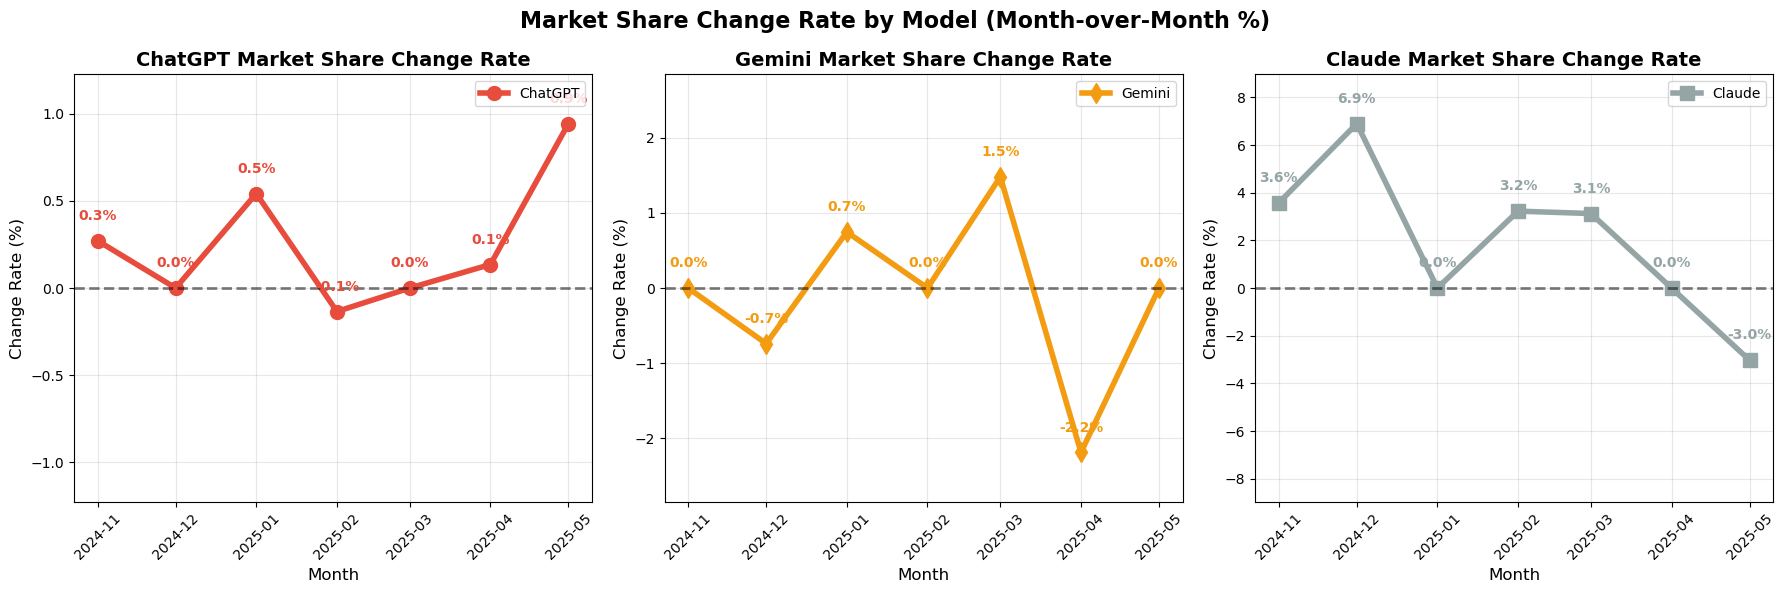

In [17]:
# Market share change rate visualization - Individual model charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Market Share Change Rate by Model (Month-over-Month %)', fontsize=16, fontweight='bold')

# Model data configuration
models_config = [
    ('ChatGPT', 'ChatGPT_Change', '#e74c3c', 'o'),
    ('Gemini', 'Gemini_Change', '#f39c12', 'd'),
    ('Claude', 'Claude_Change', '#95a5a6', 's')
]

# Calculate market share change rates
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

for i, (model_name, change_col, color, marker) in enumerate(models_config):
    ax = axes[i]

    # Plot individual model
    ax.plot(market_share_change['Month'], market_share_change[change_col],
            marker + '-', label=model_name, color=color, linewidth=4, markersize=10)

    # Add value labels on points
    for month, change in zip(market_share_change['Month'], market_share_change[change_col]):
        ax.annotate(f'{change:.1f}%', (month, change),
                   textcoords="offset points", xytext=(0,15), ha='center',
                   fontsize=10, color=color, fontweight='bold')

    # Styling
    ax.set_title(f'{model_name} Market Share Change Rate', fontsize=14, fontweight='bold')
    ax.set_ylabel('Change Rate (%)', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Set y-axis limits to focus on actual changes
    y_values = market_share_change[change_col]
    if len(y_values) > 0:
        y_range = max(abs(y_values.max()), abs(y_values.min())) * 1.3
        ax.set_ylim(-y_range, y_range)

    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

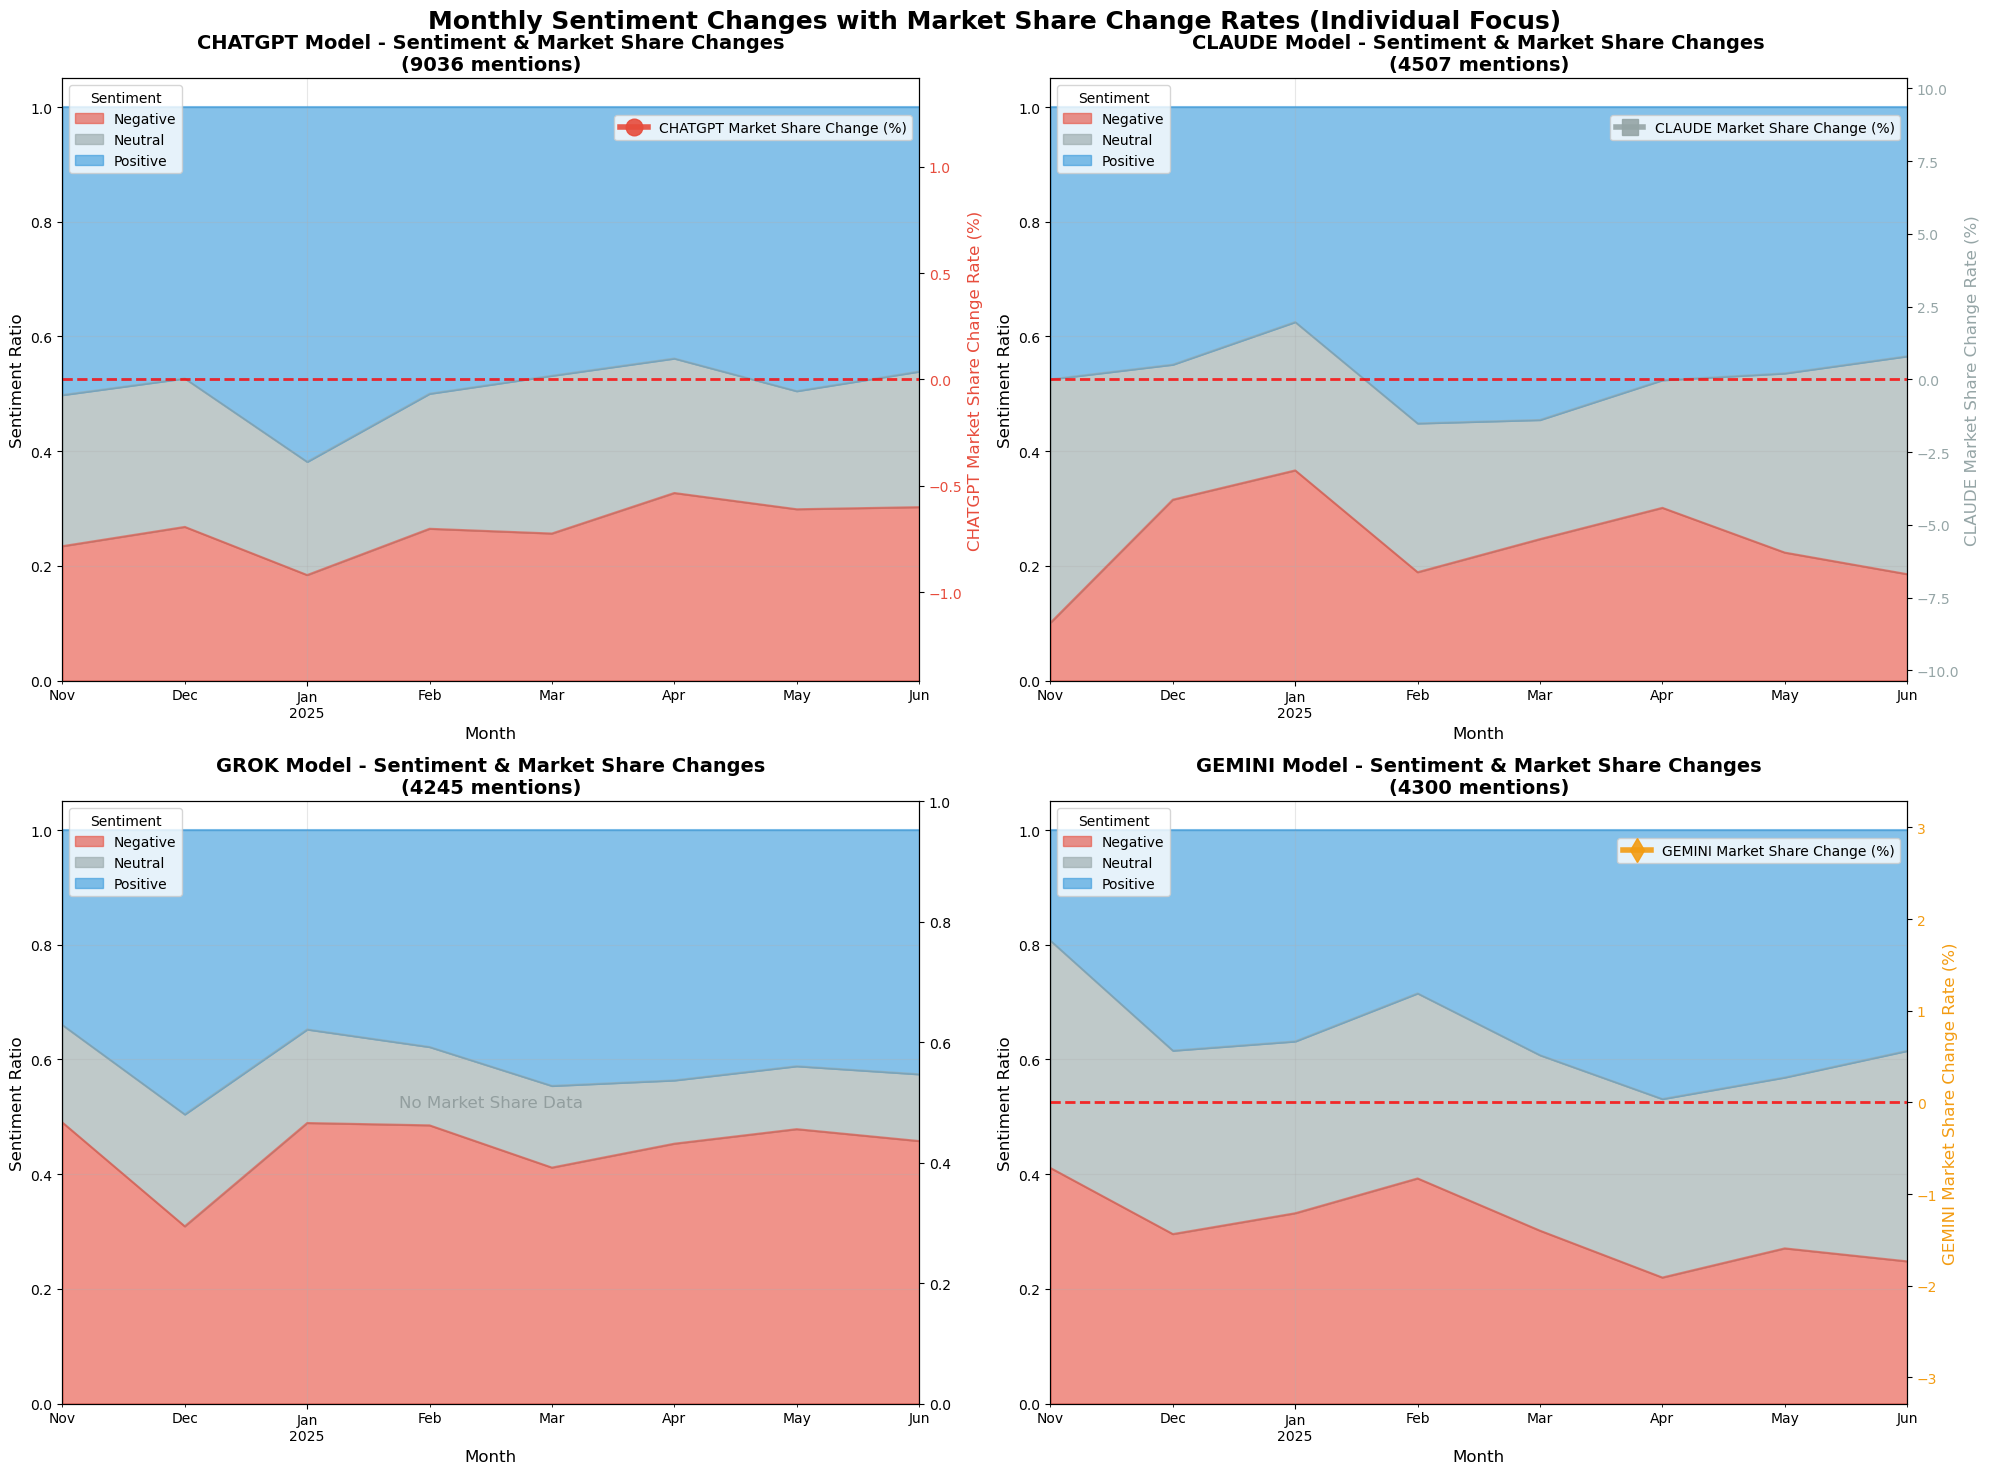

In [18]:
# Combined visualization: Sentiment changes with individual Market Share change rates
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Monthly Sentiment Changes with Market Share Change Rates (Individual Focus)', fontsize=18, fontweight='bold')

# Calculate market share change rates
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

# Model configuration for market share
market_config = {
    'chatgpt': ('ChatGPT_Change', '#e74c3c', 'o'),
    'claude': ('Claude_Change', '#95a5a6', 's'),
    'gemini': ('Gemini_Change', '#f39c12', 'd'),
    'grok': (None, None, None)
}

for i, model in enumerate(model_names):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    # Filter data where the model is mentioned in the category
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]

    if len(model_mentioned) > 0:
        # Calculate monthly sentiment distribution
        monthly_sentiment = model_mentioned.groupby(['Month', f'{model}_pred']).size().unstack(fill_value=0)
        monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)

        # Rename columns
        sentiment_columns = {}
        for col in monthly_sentiment_pct.columns:
            if col in sentiment_labels:
                sentiment_columns[col] = sentiment_labels[col]
        monthly_sentiment_pct = monthly_sentiment_pct.rename(columns=sentiment_columns)

        # Stacked area chart for sentiment
        monthly_sentiment_pct.plot(kind='area', ax=ax, alpha=0.6,
                                  color=['#e74c3c', '#95a5a6', '#3498db'])

        # Add market share change rate line (secondary y-axis)
        ax2 = ax.twinx()

        change_col, color, marker = market_config[model]
        if change_col and change_col in market_share_change.columns:
            # Plot market share change rate
            ax2.plot(market_share_change['Month'], market_share_change[change_col],
                    marker + '-', linewidth=4, markersize=12, alpha=0.9, color=color,
                    label=f'{model.upper()} Market Share Change (%)')

            # Add value labels on points
            for month, change in zip(market_share_change['Month'], market_share_change[change_col]):
                ax2.annotate(f'{change:.1f}%', (month, change),
                           textcoords="offset points", xytext=(0,20), ha='center',
                           fontsize=11, color=color, fontweight='bold',
                           bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

            # Styling for market share change
            ax2.axhline(y=0, color='red', linestyle='--', alpha=0.8, linewidth=2)
            ax2.set_ylabel(f'{model.upper()} Market Share Change Rate (%)', fontsize=12, color=color)
            ax2.tick_params(axis='y', labelcolor=color)
            ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.95))

            # Set y-axis limits to focus on actual changes
            y_values = market_share_change[change_col]
            if len(y_values) > 0:
                y_range = max(abs(y_values.max()), abs(y_values.min())) * 1.5
                if y_range > 0:
                    ax2.set_ylim(-y_range, y_range)
        else:
            # No market share data
            ax2.text(0.5, 0.5, 'No Market Share Data', ha='center', va='center',
                    transform=ax2.transAxes, fontsize=12, alpha=0.7, color='#7f8c8d')

        ax.set_title(f'{model.upper()} Model - Sentiment & Market Share Changes\n({len(model_mentioned)} mentions)',
                    fontsize=14, fontweight='bold')

    else:
        ax.set_title(f'{model.upper()} Model - No mentions found', fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes, fontsize=16)

    ax.set_ylabel('Sentiment Ratio', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.legend(title='Sentiment', loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/wt/523g88ps5cs2_z5dsn_yj80h0000gn/T/ipykernel_51608/49021505.py:50: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from current font.
  plt.tight_layout()
/var/folders/wt/523g88ps5cs2_z5dsn_yj80h0000gn/T/ipykernel_51608/49021505.py:50: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  plt.tight_layout()
/var/folders/wt/523g88ps5cs2_z5dsn_yj80h0000gn/T/ipykernel_51608/49021505.py:50: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout()
/var/folders/wt/523g88ps5cs2_z5dsn_yj80h0000gn/T/ipykernel_51608/49021505.py:50: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from current font.
  plt.tight_layout()
/var/folders/wt/523g88ps5cs2_z5dsn_yj80h0000gn/T/ipykernel_51608/49021505.py:50: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from current font.
  plt.tight_layout()
/var/folders/wt/523g88ps5cs2_z5dsn_yj80h0000gn/T/ipykernel_51608/49021505.py:50: UserWarning: Glyp

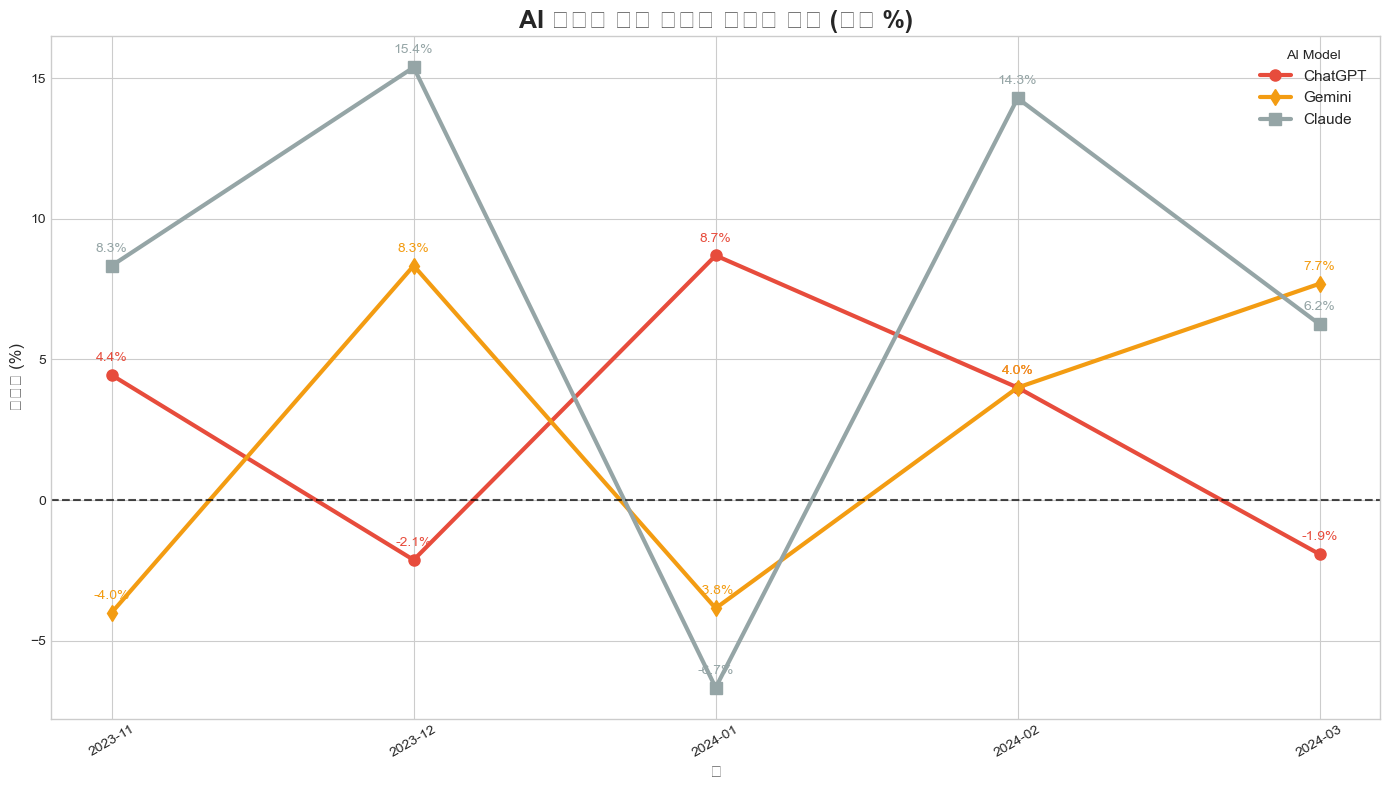

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 샘플 데이터 (기존 데이터 사용) ---
months = ['2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03']
market_share_data = {
    'Month': months,
    'ChatGPT Market Share (%)': [45, 47, 46, 50, 52, 51],
    'Gemini Market Share (%)': [25, 24, 26, 25, 26, 28],
    'ClaudeAI Market Share (%)': [12, 13, 15, 14, 16, 17]
}
market_share_df = pd.DataFrame(market_share_data)

# --- 시장 점유율 변화율 계산 ---
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()


# --- 시각화: 모든 모델을 한 차트에 그리기 ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

models_config = [
    ('ChatGPT', 'ChatGPT_Change', '#e74c3c', 'o'),
    ('Gemini', 'Gemini_Change', '#f39c12', 'd'),
    ('Claude', 'Claude_Change', '#95a5a6', 's')
]

for model_name, change_col, color, marker in models_config:
    # 선 그래프 그리기
    ax.plot(market_share_change['Month'], market_share_change[change_col],
            marker=marker, linestyle='-', label=model_name, color=color, linewidth=3, markersize=8)

    # 데이터 레이블 추가
    for month, change in zip(market_share_change['Month'], market_share_change[change_col]):
        ax.annotate(f'{change:.1f}%', (month, change),
                   textcoords="offset points", xytext=(0,10), ha='center',
                   fontsize=10, color=color)

# --- 차트 스타일링 ---
ax.set_title('AI 모델별 시장 점유율 변화율 비교 (월별 %)', fontsize=18, fontweight='bold')
ax.set_ylabel('변화율 (%)', fontsize=12)
ax.set_xlabel('월', fontsize=12)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.7, linewidth=1.5)
ax.legend(title='AI Model', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [20]:
# Simple correlation analysis visualization
correlation_results = []

# Calculate correlations for each model
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

for model in ['chatgpt', 'claude', 'gemini']:
    # Get sentiment data
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    if len(model_mentioned) > 0:
        # Calculate net sentiment by month
        monthly_net_sentiment = model_mentioned.groupby('Month')[f'{model}_pred'].apply(
            lambda x: (x == 1).sum() - (x == -1).sum()  # Net positive sentiment count
        )

        # Get market share change data
        if model == 'chatgpt':
            market_change = market_share_change.set_index('Month')['ChatGPT_Change']
        elif model == 'claude':
            market_change = market_share_change.set_index('Month')['Claude_Change']
        elif model == 'gemini':
            market_change = market_share_change.set_index('Month')['Gemini_Change']

        # Align data by common months
        common_months = monthly_net_sentiment.index.intersection(market_change.index)
        if len(common_months) > 1:
            sentiment_data = monthly_net_sentiment.reindex(common_months)
            market_data = market_change.reindex(common_months)

            # Calculate correlation
            if sentiment_data.std() > 0 and market_data.std() > 0:
                correlation = sentiment_data.corr(market_data)
                correlation_results.append({
                    'Model': model.upper(),
                    'Correlation': correlation,
                    'Sample_Size': len(common_months)
                })

# Create correlation visualization
if correlation_results:
    corr_df = pd.DataFrame(correlation_results)

    plt.figure(figsize=(10, 6))

    # Bar chart with correlation values
    colors = ['#e74c3c', '#95a5a6', '#f39c12']
    bars = plt.bar(corr_df['Model'], corr_df['Correlation'], color=colors, alpha=0.7, edgecolor='black', linewidth=2)

    # Add value labels on bars
    for bar, corr in zip(bars, corr_df['Correlation']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (0.02 if height >= 0 else -0.05),
                f'{corr:.3f}', ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=14, fontweight='bold')

    plt.title('Correlation: Net Sentiment vs Market Share Change Rate', fontsize=16, fontweight='bold')
    plt.ylabel('Correlation Coefficient', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.ylim(-1, 1)
    plt.grid(True, alpha=0.3, axis='y')

    # Add interpretation text
    plt.text(0.02, 0.98, 'Positive: Sentiment ↑ → Market Share ↑\nNegative: Sentiment ↑ → Market Share ↓',
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))

    plt.tight_layout()
    plt.show()

    # Print correlation summary
    print("Correlation Summary:")
    print("=" * 50)
    for _, row in corr_df.iterrows():
        strength = "Strong" if abs(row['Correlation']) > 0.7 else "Moderate" if abs(row['Correlation']) > 0.3 else "Weak"
        direction = "Positive" if row['Correlation'] > 0 else "Negative"
        print(f"{row['Model']}: {row['Correlation']:.3f} ({strength} {direction}) - {row['Sample_Size']} months")

else:
    print("No correlation data available")

No correlation data available


In [21]:
# Debug: Check data availability for correlation
print("=== Data Availability Check ===")

# Check market share data
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

print(f"Market share data shape: {market_share_change.shape}")
print(f"Market share months: {market_share_change['Month'].tolist()}")

# Check sentiment data
for model in ['chatgpt', 'claude', 'gemini']:
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]
    print(f"\n{model.upper()} mentioned: {len(model_mentioned)} posts")

    if len(model_mentioned) > 0:
        monthly_sentiment = model_mentioned.groupby('Month')[f'{model}_pred'].apply(
            lambda x: (x == 1).sum() - (x == -1).sum()
        )
        print(f"  Sentiment months: {len(monthly_sentiment)} months")
        print(f"  Sentiment values: {monthly_sentiment.tolist()}")

        # Check overlap with market share months
        market_months = market_share_change.set_index('Month').index
        common_months = monthly_sentiment.index.intersection(market_months)
        print(f"  Common months: {len(common_months)} - {common_months.tolist()}")

=== Data Availability Check ===
Market share data shape: (5, 7)
Market share months: ['2023-11', '2023-12', '2024-01', '2024-02', '2024-03']

CHATGPT mentioned: 9036 posts
  Sentiment months: 8 months
  Sentiment values: [119, 158, 227, 145, 159, 129, 541, 323]
  Common months: 0 - []

CLAUDE mentioned: 4507 posts
  Sentiment months: 8 months
  Sentiment values: [52, 62, 2, 221, 108, 78, 303, 250]
  Common months: 0 - []

GEMINI mentioned: 4300 posts
  Sentiment months: 8 months
  Sentiment values: [-106, 55, 8, -20, 40, 109, 194, 98]
  Common months: 0 - []


In [22]:
# Fixed correlation analysis with proper data alignment
correlation_results = []

# Prepare market share data with proper date format
market_share_change = market_share_df.copy()
market_share_change['ChatGPT_Change'] = market_share_df['ChatGPT Market Share (%)'].pct_change() * 100
market_share_change['Gemini_Change'] = market_share_df['Gemini Market Share (%)'].pct_change() * 100
market_share_change['Claude_Change'] = market_share_df['ClaudeAI Market Share (%)'].pct_change() * 100
market_share_change = market_share_change.dropna()

# Convert market share months to period format for matching
market_share_change['Month_Period'] = market_share_change['Month'].dt.to_period('M')

print("=== Correlation Analysis ===")

for model in ['chatgpt', 'claude', 'gemini']:
    model_mentioned = df[df['category_parsed'].apply(lambda x: model in x)]

    if len(model_mentioned) > 0:
        # Calculate monthly sentiment metrics
        monthly_sentiment = model_mentioned.groupby('Month')[f'{model}_pred'].apply(
            lambda x: pd.Series({
                'net_sentiment': (x == 1).sum() - (x == -1).sum(),
                'positive_ratio': (x == 1).mean(),
                'negative_ratio': (x == -1).mean()
            })
        ).unstack()

        # Get corresponding market share change
        if model == 'chatgpt':
            market_col = 'ChatGPT_Change'
        elif model == 'claude':
            market_col = 'Claude_Change'
        elif model == 'gemini':
            market_col = 'Gemini_Change'

        # Align data by matching periods
        market_data = market_share_change.set_index('Month_Period')[market_col]

        # Find common periods
        common_periods = monthly_sentiment.index.intersection(market_data.index)
        print(f"\n{model.upper()}: {len(common_periods)} common months")

        if len(common_periods) >= 2:  # Need at least 2 points for correlation
            sentiment_aligned = monthly_sentiment.loc[common_periods, 'net_sentiment']
            market_aligned = market_data.loc[common_periods]

            # Remove any NaN values
            valid_mask = sentiment_aligned.notna() & market_aligned.notna()
            sentiment_clean = sentiment_aligned[valid_mask]
            market_clean = market_aligned[valid_mask]

            print(f"  Valid data points: {len(sentiment_clean)}")

            if len(sentiment_clean) >= 2 and sentiment_clean.std() > 0 and market_clean.std() > 0:
                correlation = sentiment_clean.corr(market_clean)
                correlation_results.append({
                    'Model': model.upper(),
                    'Correlation': correlation,
                    'Sample_Size': len(sentiment_clean),
                    'Sentiment_Range': f"{sentiment_clean.min():.1f} to {sentiment_clean.max():.1f}",
                    'Market_Range': f"{market_clean.min():.2f}% to {market_clean.max():.2f}%"
                })
                print(f"  Correlation: {correlation:.3f}")
            else:
                print(f"  Insufficient variation in data for correlation")

# Create visualization
if correlation_results:
    corr_df = pd.DataFrame(correlation_results)

    plt.figure(figsize=(12, 8))

    # Create bar chart
    colors = ['#e74c3c', '#95a5a6', '#f39c12']
    bars = plt.bar(corr_df['Model'], corr_df['Correlation'],
                   color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    # Add value labels on bars
    for i, (bar, row) in enumerate(zip(bars, corr_df.itertuples())):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (0.03 if height >= 0 else -0.06),
                f'{row.Correlation:.3f}\n(n={row.Sample_Size})',
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=12, fontweight='bold')

    plt.title('Correlation: Net Sentiment vs Market Share Change Rate', fontsize=16, fontweight='bold')
    plt.ylabel('Correlation Coefficient', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.ylim(-1, 1)
    plt.grid(True, alpha=0.3, axis='y')

    # Add interpretation guide
    plt.text(0.02, 0.98,
             'Positive: Better sentiment → Higher market share growth\n' +
             'Negative: Better sentiment → Lower market share growth\n' +
             'Near zero: No clear relationship',
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # Print detailed results
    print("\n" + "="*60)
    print("CORRELATION ANALYSIS RESULTS")
    print("="*60)
    for _, row in corr_df.iterrows():
        strength = ("Strong" if abs(row['Correlation']) > 0.7 else
                   "Moderate" if abs(row['Correlation']) > 0.3 else "Weak")
        direction = "Positive" if row['Correlation'] > 0 else "Negative"

        print(f"\n{row['Model']}:")
        print(f"  Correlation: {row['Correlation']:.3f} ({strength} {direction})")
        print(f"  Sample size: {row['Sample_Size']} months")
        print(f"  Sentiment range: {row['Sentiment_Range']}")
        print(f"  Market change range: {row['Market_Range']}")

else:
    print("\nNo sufficient correlation data available")
    print("Possible reasons:")
    print("- Insufficient overlapping time periods")
    print("- Insufficient variation in sentiment or market data")
    print("- Data alignment issues")

AttributeError: Can only use .dt accessor with datetimelike values